# Notebook 5 — Final Evaluation, Visualisation and Report Figures

## Purpose of this notebook

This notebook performs the final evaluation and visual analysis for the weakly supervised Video Anomaly Detection project.

The previous notebooks prepare metadata, feature bags, dataloaders, model definitions and trained checkpoints. This notebook reloads the saved models and produces the final metrics, plots and report-ready outputs.

The main tasks in this notebook are:

1. Reload the Baseline MIL and Attention MIL checkpoints.
2. Evaluate models on validation and test splits.
3. Compare max pooling and top-k pooling.
4. Generate final AUC and AP tables.
5. Evaluate the integrated Attention MIL + CLIP semantic-head model.
6. Produce semantic confusion matrices for the CLIP extension.
7. Generate Precision-Recall curves, anomaly score curves, UMAP/t-SNE plots and attention heatmaps.
8. Summarise limitations and final report results.
9. Evaluate the separate post-hoc CLIP text semantic label suggestion method.

## Pipeline position

```text
Notebook 1: metadata, splits and configuration
        ↓
Notebook 2: feature bags, manifests and dataloaders
        ↓
Notebook 3: model definitions, pooling and losses
        ↓
Notebook 4: model training and checkpoint saving
        ↓
Notebook 5: final evaluation, visualisation and report figures
```

## Final evaluation focus

The main official results are video-level weakly supervised MIL metrics:

```text
AUC = Area Under the ROC Curve
AP  = Average Precision
```

The final report uses **top-k pooling** as the main video-level scoring method because it is more stable than relying on a single maximum-scoring segment.

The reported inference time is post-feature inference time for the MIL model head. It does not include raw video decoding or feature extraction time.


# Notebook configuration handoff

This notebook begins by loading the shared session file created earlier in the pipeline:

```text
artifacts/task1_session.json
```

The session file restores the project paths, dataset mode, feature mode, number of temporal segments, MIL input dimension, CLIP settings and output directories.

Loading this file ensures that the evaluation notebook uses the same configuration as the data preparation and training notebooks.

The bootstrap cell restores:

- project root paths;
- metadata and split directories;
- feature directories;
- dataset mode: UCF, XD, or both;
- feature mode: 2D, 3D, or fusion;
- number of temporal segments;
- MIL input dimension;
- CLIP semantic settings;
- checkpoint and figure directories;
- helper functions for saving figures.

This keeps the full pipeline reproducible and avoids manually redefining paths or feature settings.


In [1]:
# run first on a fresh kernel
import json
import os
import platform
from pathlib import Path

import torch

def _submission_root() -> Path:
    env = os.environ.get("VAD_SUBMISSION_ROOT")
    if env:
        return Path(env).resolve()
    cwd = Path.cwd().resolve()
    if cwd.name == "notebooks":
        return cwd.parent
    return cwd

SUBMISSION_ROOT = _submission_root()
SESSION_PATH = SUBMISSION_ROOT / "artifacts" / "task1_session.json"
if not SESSION_PATH.exists():
    raise FileNotFoundError(
        f"Missing {SESSION_PATH}. Run Task 1 to completion and execute its session-export cell, "
        "or set VAD_SUBMISSION_ROOT to your dev_submission folder."
    )

sess = json.loads(SESSION_PATH.read_text(encoding="utf-8"))

PROJECT_ROOT = Path(sess["project_root"])
PROCESSED_ROOT = sess["processed_root"]
DATA_ROOT = sess["data_root"]
XD_VIOLENCE_ROOT = sess["xd_violence_root"]
I3D_FEATURES_DIR = Path(sess["i3d_features_dir"])
METADATA_DIR = Path(sess["metadata_dir"])
SPLITS_DIR = Path(sess["splits_dir"])
FEATURES_DIR = Path(sess["features_dir"])
FEATURES_DIR_XD = Path(sess["features_dir_xd"])
FEATURES_3D_DIR = Path(sess["features_3d_dir"])
FEATURES_FUSION_DIR = Path(sess["features_fusion_dir"])
RESULTS_DIR = Path(sess["results_dir"])

USE_RUNS_DIR = bool(sess["use_runs_dir"])
RUN_TAG = sess["run_tag"]
CFG = sess["cfg"]
SEED = int(sess["seed"])
NUM_SEGMENTS = int(sess["num_segments"])
DATASET_MODE = sess["dataset_mode"]
USE_FUSION = bool(sess["use_fusion"])
USE_3D_FEATURES = bool(sess["use_3d_features"])
FEATURE_DIM = int(sess["feature_dim"])
FEATURE_DIM_3D = int(sess["feature_dim_3d"])
XD_FEATURE_DIM = int(sess["xd_feature_dim"])
XD_SEGMENTS_RAW = int(sess["xd_segments_raw"])
XD_STREAM_OUT_DIM = int(sess["xd_stream_out_dim"])
FRAMES_PER_SEGMENT = int(sess["frames_per_segment"])
RESIZE_HW = tuple(sess["resize_hw"])
CLIP_LEN = int(sess["clip_len"])
CLIP_STRIDE = int(sess["clip_stride"])
TRAIN_RATIO = float(sess["train_ratio"])
VAL_RATIO = float(sess["val_ratio"])
TEST_RATIO = float(sess["test_ratio"])
IN_COLAB = bool(sess["in_colab"])
PHASE_ACTIVE = int(sess.get("phase_active", 2))

USE_CLIP_TEXT_EXTRA_CREDIT = bool(sess.get("use_clip_text_extra_credit", True))

ANOMALY_LABEL_SET = sess.get("anomaly_label_set", [
    "normal",
    "abuse",
    "arrest",
    "arson",
    "assault",
    "burglary",
    "explosion",
    "fighting",
    "road accident",
    "robbery",
    "shooting",
    "shoplifting",
    "stealing",
    "vandalism",
    "violence",
])

_ = platform.system()
print("Loaded session:", SESSION_PATH)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_ROOT:", PROCESSED_ROOT)

FORCE_CPU = False

def select_torch_device(force_cpu: bool = False) -> torch.device:
    if force_cpu:
        print("TORCH_DEVICE: cpu (FORCE_CPU=True)")
        return torch.device("cpu")
    if not torch.cuda.is_available():
        print("TORCH_DEVICE: cpu (CUDA not available)")
        return torch.device("cpu")
    try:
        x = torch.randn(1, 3, 224, 224, device="cuda")
        w = torch.randn(64, 3, 7, 7, device="cuda")
        _ = torch.nn.functional.conv2d(x, w, padding=3)
        del _, w, x
        torch.cuda.empty_cache()
        print("TORCH_DEVICE: cuda (smoke test passed)")
        return torch.device("cuda")
    except Exception as e:
        print(f"CUDA reported but ops failed ({str(e)[:120]}...); using CPU")
        return torch.device("cpu")

TORCH_DEVICE = select_torch_device(FORCE_CPU)
device = TORCH_DEVICE

if USE_FUSION:
    MIL_INPUT_DIM = FEATURE_DIM + FEATURE_DIM_3D
elif USE_3D_FEATURES:
    MIL_INPUT_DIM = FEATURE_DIM_3D
else:
    MIL_INPUT_DIM = FEATURE_DIM

MIL_DUMMY_T = 32 if (USE_3D_FEATURES or USE_FUSION) else NUM_SEGMENTS

def ucf_feature_dir() -> Path:
    if USE_FUSION:
        return FEATURES_FUSION_DIR
    return FEATURES_3D_DIR if USE_3D_FEATURES else FEATURES_DIR

# figures: save under RESULTS_DIR/figures (always define here )
import re
import matplotlib.pyplot as plt


def _sanitize_fig_name(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9\-_.]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_.")
    return name or "figure"


FIGURES_DIR = (RESULTS_DIR / "figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name: str, fig=None, *, dpi: int = 200, close: bool = False):
    fig = fig or plt.gcf()
    out = FIGURES_DIR / f"{_sanitize_fig_name(name)}.png"
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    if close:
        plt.close(fig)
    print(f"Saved figure: {out}")
    return out

print("Bootstrap OK — continue with Section 6 onward.")

print("USE_CLIP_TEXT_EXTRA_CREDIT:", USE_CLIP_TEXT_EXTRA_CREDIT)
print("ANOMALY_LABEL_SET size:", len(ANOMALY_LABEL_SET))
print("MIL_INPUT_DIM:", MIL_INPUT_DIM)


Loaded session: /scratch/VAD/artifacts/task1_session.json
PROJECT_ROOT: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217
PROCESSED_ROOT: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/processed
TORCH_DEVICE: cuda (smoke test passed)
Bootstrap OK — continue with Section 6 onward.
USE_CLIP_TEXT_EXTRA_CREDIT: True
ANOMALY_LABEL_SET size: 15
MIL_INPUT_DIM: 512


# Figure output setup

The bootstrap cell defines the figure output directory and the helper function used to save report-ready plots.

Generated figures are saved under the project results or figures directory so that they can be reused in the final report and viva preparation material.

If the notebook is restarted, the bootstrap cell should be run before any plotting cells so that the figure paths and saving utilities are available.


# 1. Load metadata splits

This section loads the train, validation and test split files created earlier in the pipeline.

For UCF-Crime, the required files are:

```text
train_df.pkl
val_df.pkl
test_df.pkl
```

For XD-Violence, when `DATASET_MODE` is set to `xd` or `both`, the required files are:

```text
xd_train_df.pkl
xd_val_df.pkl
xd_test_df.pkl
```

These dataframes contain clip-level metadata and binary normal/anomaly labels. They are used to rebuild or load the feature manifests required for final evaluation.

Using the same split files across all notebooks ensures that training, validation and test evaluation remain consistent.


In [2]:
# Load UCF train/val/test splits produced by Task 1 
import pandas as pd

for _name in ("train_df", "val_df", "test_df"):
    _p = SPLITS_DIR / f"{_name}.pkl"
    if not _p.exists():
        raise FileNotFoundError(
            f"Missing {_p}. Run Task 1 through the split + session-export cells first."
        )

train_df = pd.read_pickle(SPLITS_DIR / "train_df.pkl")
val_df = pd.read_pickle(SPLITS_DIR / "val_df.pkl")
test_df = pd.read_pickle(SPLITS_DIR / "test_df.pkl")
print("Loaded Task 1 splits:", len(train_df), "train |", len(val_df), "val |", len(test_df), "test")

if DATASET_MODE in ("xd", "both"):
    for _name in ("xd_train_df", "xd_val_df", "xd_test_df"):
        _p = SPLITS_DIR / f"{_name}.pkl"
        if not _p.exists():
            raise FileNotFoundError(
                f"Missing {_p}. In Task 1, run the XD metadata/split cells, then Section 5 "
                "(writes xd_*.pkl next to UCF splits), then session export."
            )
    xd_train_df = pd.read_pickle(SPLITS_DIR / "xd_train_df.pkl")
    xd_val_df = pd.read_pickle(SPLITS_DIR / "xd_val_df.pkl")
    xd_test_df = pd.read_pickle(SPLITS_DIR / "xd_test_df.pkl")
    print(
        "Loaded XD splits:",
        len(xd_train_df),
        "train |",
        len(xd_val_df),
        "val |",
        len(xd_test_df),
        "test",
    )


Loaded Task 1 splits: 1420 train | 190 val | 290 test
Loaded XD splits: 15816 train | 3954 val | 4000 test


# 2. Feature manifest helpers

This section defines helper functions for creating manifest CSV files from the saved feature bags.

A manifest connects each video clip to its saved `.npy` feature bag and binary label. Each row contains:

```text
clip_id
label
feature_path
num_segments
```

The main manifest files are:

```text
train_manifest.csv
val_manifest.csv
test_manifest.csv
```

The evaluation code does not read raw frames directly. It reads temporal feature bags through these manifest file paths.

The manifest builder checks that each expected feature file exists before adding it to the manifest. This prevents missing or failed feature extractions from being included in final evaluation.


In [3]:
# Define build_feature_manifest() and save_manifests(); columns: clip_id, label, feature_path, num_segments.
if PHASE_ACTIVE < 2:
    raise RuntimeError("Phase 1 only. Set PHASE_ACTIVE = 2 in Config to run pipeline.")
import pandas as pd
from pathlib import Path

import numpy as np

def build_feature_manifest(split_df: pd.DataFrame, features_dir: Path) -> pd.DataFrame:
    rows = []
    for _, row in split_df.iterrows():
        clip_id = row["clip_id"]
        label = int(row["label"])
        fname = clip_id if str(clip_id).endswith(".npy") else f"{clip_id}.npy"
        feature_path = features_dir / fname
        if not feature_path.exists():
            continue
        bag = np.load(feature_path)
        rows.append({"clip_id": clip_id, "label": label, "feature_path": str(feature_path), "num_segments": bag.shape[0]})
    return pd.DataFrame(rows)

def save_manifests(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, features_dir: Path, out_dir: Path) -> None:
    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        manifest = build_feature_manifest(df, features_dir)
        path = out_dir / f"{name}_manifest.csv"
        manifest.to_csv(path, index=False)
        print(f"{name}_manifest.csv:", len(manifest), "rows")

# Run after feature extraction:
# save_manifests(train_df, val_df, test_df, FEATURES_DIR, METADATA_DIR)
print("Run the cell below to write manifest CSVs to METADATA_DIR.")

Run the cell below to write manifest CSVs to METADATA_DIR.


In [4]:
# Write train/val/test_manifest.csv to METADATA_DIR. Run after Section 5 (splits) and feature extraction.
_ucf_dir = ucf_feature_dir()
save_manifests(train_df, val_df, test_df, _ucf_dir, METADATA_DIR)

train_manifest.csv: 1420 rows
val_manifest.csv: 190 rows
test_manifest.csv: 290 rows


# 3. Build final MIL manifests

This section builds the final train, validation and test manifests used by the evaluation pipeline.

The manifest construction depends on `DATASET_MODE`:

```text
ucf  → UCF-Crime only
xd   → XD-Violence only
both → combined UCF-Crime + XD-Violence
```

For the submitted run, the project uses:

```text
DATASET_MODE = both
feature_mode = 3d
MIL input dimension = 512
```

The final manifests therefore combine UCF-Crime R(2+1)D feature bags and XD-Violence RGB+Flow I3D fused feature bags, both aligned to the same 512-dimensional input format.

These manifests are used by the dataloaders and final evaluation functions.


In [5]:
# Build train_manifest_df and val_manifest_df from UCF and/or XD according to DATASET_MODE. Required before DataLoader/training.
if PHASE_ACTIVE < 2:
    raise RuntimeError("Phase 1 only. Set PHASE_ACTIVE = 2 in Config to run pipeline.")
_ucf_feat_dir = ucf_feature_dir()
if DATASET_MODE == "ucf":
    train_manifest_df = build_feature_manifest(train_df, _ucf_feat_dir)
    val_manifest_df = build_feature_manifest(val_df, _ucf_feat_dir)
    print("Manifests from UCF. Train:", len(train_manifest_df), "| Val:", len(val_manifest_df))
elif DATASET_MODE == "xd":
    if "xd_train_df" not in globals() or "xd_val_df" not in globals():
        raise RuntimeError("Run Phase 2 (XD metadata) and Section 2b (XD feature bags) first.")
    train_manifest_df = build_feature_manifest(xd_train_df, FEATURES_DIR_XD)
    val_manifest_df = build_feature_manifest(xd_val_df, FEATURES_DIR_XD)
    print("Manifests from XD. Train:", len(train_manifest_df), "| Val:", len(val_manifest_df))
elif DATASET_MODE == "both":
    ucf_train = build_feature_manifest(train_df, _ucf_feat_dir)
    ucf_val = build_feature_manifest(val_df, _ucf_feat_dir)
    xd_train_m = build_feature_manifest(xd_train_df, FEATURES_DIR_XD)
    xd_val_m = build_feature_manifest(xd_val_df, FEATURES_DIR_XD)
    train_manifest_df = pd.concat([ucf_train, xd_train_m], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    val_manifest_df = pd.concat([ucf_val, xd_val_m], ignore_index=True)
    print("Manifests from UCF+XD. Train:", len(train_manifest_df), "| Val:", len(val_manifest_df))
else:
    raise ValueError("DATASET_MODE must be 'ucf', 'xd', or 'both'.")
if DATASET_MODE == "ucf":
    test_manifest_df = build_feature_manifest(test_df, _ucf_feat_dir)
elif DATASET_MODE == "xd":
    test_manifest_df = build_feature_manifest(xd_test_df, FEATURES_DIR_XD)
else:
    test_manifest_df = pd.concat([build_feature_manifest(test_df, _ucf_feat_dir), build_feature_manifest(xd_test_df, FEATURES_DIR_XD)], ignore_index=True)
train_manifest_df.to_csv(METADATA_DIR / "train_manifest.csv", index=False)
val_manifest_df.to_csv(METADATA_DIR / "val_manifest.csv", index=False)
test_manifest_df.to_csv(METADATA_DIR / "test_manifest.csv", index=False)
if len(train_manifest_df) < 50 or len(val_manifest_df) < 20:
    print("Warning: very few clips in manifest. Validation AUC will be unreliable. Run more feature extraction (UCF and/or XD Section 2b), then re-run manifest and DataLoader.")


Manifests from UCF+XD. Train: 17236 | Val: 4144


# 4. Bag feature normalisation

This section loads or computes feature normalisation statistics for the temporal feature bags.

The statistics are fitted using training feature bags only:

```text
mean
standard deviation
feature dimension
number of training clips
number of training segments
```

The same training-set mean and standard deviation are applied to validation and test feature bags.

This avoids data leakage because validation and test data do not influence the scaling parameters used by the models.

The saved statistics file is:

```text
bag_norm_stats.npz
```


In [6]:
# Bag normalization: fit mean/std on train bags
import numpy as np
_norm_path = METADATA_DIR / "bag_norm_stats.npz"
if len(train_manifest_df) > 0:
    segments = []
    for _, row in train_manifest_df.iterrows():
        bag = np.load(row.feature_path)
        segments.append(bag)
    all_segments = np.concatenate(segments, axis=0)
    _mean = all_segments.mean(axis=0).astype(np.float32)
    _std = (all_segments.std(axis=0) + 1e-6).astype(np.float32)
    np.savez(_norm_path, mean=_mean, std=_std)
    print("Bag norm: fitted on", len(train_manifest_df), "clips; saved to", _norm_path)
else:
    print("Train manifest empty; skipping bag norm fit.")
    


Bag norm: fitted on 17236 clips; saved to /scratch/VAD/artifacts/metadata/bag_norm_stats.npz


# 5. PyTorch MIL feature dataset

This section defines the PyTorch dataset class used to load `.npy` feature bags from the manifest files.

Each dataset item contains:

```text
features
label
length
```

where:

- `features` is the temporal segment feature bag;
- `label` is the binary video-level normal/anomaly label;
- `length` records the number of valid temporal segments.

If normalisation statistics are available, the dataset applies the training-set mean and standard deviation to each feature bag.

This dataset class is reused for validation, test evaluation, visualisation and CLIP semantic analysis.


In [7]:
# PyTorch Dataset: loads .npy feature bags; optional norm_stats (mean, std) applied (fit on train, same for val/test).
import torch
from torch.utils.data import Dataset
import numpy as np

class MILFeatureDataset(Dataset):
    def __init__(self, manifest_df, norm_stats=None):
        self.df = manifest_df.reset_index(drop=True)
        self.norm_stats = norm_stats  # (mean, std) each shape (D,) or None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        features = np.load(row.feature_path).astype(np.float32)
        if self.norm_stats is not None:
            mean, std = self.norm_stats
            features = (features - mean) / std
        T = features.shape[0]
        return torch.tensor(features, dtype=torch.float32), torch.tensor(row.label), torch.tensor(T, dtype=torch.long)


# 6. MIL dataloaders

This section creates dataloaders for the train, validation and test feature manifests.

The dataloader setup includes:

```text
MILFeatureDataset
BalancedBatchSampler
collate_pad_bags
train_loader
val_loader
test_loader
```

The collate function pads variable-length feature bags within a batch and returns tensors in the format expected by the evaluation models:

```text
features: [batch_size, temporal_segments, feature_dim]
labels:   [batch_size]
lengths:  [batch_size]
```

For the submitted configuration, the expected feature dimension is:

```text
feature_dim = 512
```


In [8]:
# Create train_loader and val_loader from MILFeatureDataset. Requires non-empty train_manifest_df and val_manifest_df.
if PHASE_ACTIVE < 2:
    raise RuntimeError("Phase 1 only. Set PHASE_ACTIVE = 2 in Config to run pipeline.")
from torch.utils.data import DataLoader, Sampler

class BalancedBatchSampler(Sampler):
    """Yield batch indices so each batch has (approx) equal normal and anomaly samples."""
    def __init__(self, labels, batch_size, seed=42):
        self.labels = np.asarray(labels)
        self.batch_size = batch_size
        self.seed = seed
        self.normal_idx = np.where(self.labels == 0)[0]
        self.anomaly_idx = np.where(self.labels == 1)[0]

    def __iter__(self):
        rng = np.random.default_rng(self.seed)
        n_half = self.batch_size // 2
        n_batches = (len(self.labels) + self.batch_size - 1) // self.batch_size
        for _ in range(n_batches):
            n_n = min(n_half, len(self.normal_idx))
            n_a = min(self.batch_size - n_n, len(self.anomaly_idx))
            if n_n == 0: n_n = min(1, len(self.normal_idx))
            if n_a == 0: n_a = min(1, len(self.anomaly_idx))
            idx_n = rng.choice(self.normal_idx, size=n_n, replace=len(self.normal_idx) < n_n)
            idx_a = rng.choice(self.anomaly_idx, size=n_a, replace=len(self.anomaly_idx) < n_a)
            yield list(np.concatenate([idx_n, idx_a]))

    def __len__(self):
        return (len(self.labels) + self.batch_size - 1) // self.batch_size

def collate_pad_bags(batch):
    """Pad variable-length feature bags to max T in batch; return (feats, labels, lengths)."""
    feats = torch.nn.utils.rnn.pad_sequence([b[0] for b in batch], batch_first=True, padding_value=0.0)
    labels = torch.stack([b[1] for b in batch])
    lengths = torch.stack([b[2] for b in batch])
    return feats, labels, lengths

if len(train_manifest_df) == 0 or len(val_manifest_df) == 0:
    raise ValueError(
        "Manifests are empty. Run Section 7 (feature extraction) first: "
        "extract_and_save_clip_features(train_df/val_df, FEATURES_DIR) to create .npy feature bags."
    )

_norm_path = METADATA_DIR / "bag_norm_stats.npz"
norm_stats = None
if _norm_path.exists():
    _d = np.load(_norm_path)
    norm_stats = (_d["mean"], _d["std"])
    print("Using bag normalization (fit on train).")

train_dataset = MILFeatureDataset(train_manifest_df, norm_stats=norm_stats)
val_dataset = MILFeatureDataset(val_manifest_df, norm_stats=norm_stats)

USE_BALANCED_SAMPLER = True  # Each batch has both classes when possible
batch_size = int(CFG["batch_size"]) if "CFG" in globals() else 8
if USE_BALANCED_SAMPLER and len(train_manifest_df["label"].unique()) > 1:
    bal_sampler = BalancedBatchSampler(train_manifest_df["label"].values, batch_size, seed=SEED)
    train_loader = DataLoader(train_dataset, batch_sampler=bal_sampler, collate_fn=collate_pad_bags)
else:
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_pad_bags)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_pad_bags)

if USE_FUSION:
    _xb, _, _ = next(iter(train_loader))
    assert int(_xb.shape[-1]) == int(FEATURE_DIM + FEATURE_DIM_3D), _xb.shape
    print("Fusion batch shape:", tuple(_xb.shape), "feature_dim=", int(_xb.shape[-1]))

if len(test_manifest_df) > 0:
    test_dataset = MILFeatureDataset(test_manifest_df, norm_stats=norm_stats)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_pad_bags)
else:
    test_loader = None
    print("test_manifest is empty — test_loader not created (test-set eval skipped).")

Using bag normalization (fit on train).


# 7. Final evaluation model definitions

This section defines the model architectures used to reload trained checkpoints for final evaluation.

The two main binary anomaly-detection models are:

1. **Baseline MIL**  
   A feed-forward segment scorer that produces one anomaly logit per temporal segment.

2. **Attention MIL**  
   A temporal self-attention model that allows segment features to exchange information before anomaly scoring.

The checkpoint loading process requires these model definitions to match the architectures used during training in Notebook 4.

Both models receive temporal feature bags in the format:

```text
input: [B, T, D]
```

and produce segment-level anomaly logits:

```text
output: [B, T]
```

The segment logits are later pooled into video-level anomaly scores using max or top-k pooling.


In [9]:
# ============================================================================
# MODEL DEFINITIONS FOR FINAL EVALUATION
# ============================================================================
import torch
import torch.nn as nn


class MILModel(nn.Module):
    """
    Baseline MIL segment scorer.

    Input:
        x: [B, T, D]

    Output:
        logits: [B, T]
    """

    def __init__(self, feature_dim=512, input_dim=None, dropout=0.3):
        super().__init__()

        input_dim = input_dim if input_dim is not None else feature_dim

        self.input_proj = (
            nn.Linear(input_dim, feature_dim)
            if input_dim != feature_dim
            else nn.Identity()
        )

        self.net = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.input_proj(x)
        logits = self.net(x).squeeze(-1)
        return logits


class TransformerEncoderLayerWithWeights(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            d_model,
            nhead,
            dropout=dropout,
            batch_first=True,
        )

        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, need_weights=True):
        src2, attn_weights = self.self_attn(
            src,
            src,
            src,
            need_weights=need_weights,
        )

        src = src + self.dropout(src2)
        src = self.norm1(src)

        src2 = self.linear2(
            self.dropout(torch.nn.functional.relu(self.linear1(src)))
        )

        src = src + self.dropout(src2)
        src = self.norm2(src)

        return src, attn_weights if need_weights else None


class MILModelWithAttention(nn.Module):
    """
    Temporal attention MIL model.

    This matches the attention architecture used in Notebook 4 if you kept
    MILModelWithAttention and aliased it to AttentionMILModel.
    """

    def __init__(
        self,
        feature_dim=512,
        hidden_dim=256,
        num_heads=4,
        dropout=0.3,
        input_dim=None,
    ):
        super().__init__()

        input_dim = input_dim if input_dim is not None else feature_dim

        self.input_proj = (
            nn.Linear(input_dim, feature_dim)
            if input_dim != feature_dim
            else nn.Identity()
        )

        self.proj = nn.Linear(feature_dim, hidden_dim)

        self.layer1 = TransformerEncoderLayerWithWeights(
            hidden_dim,
            num_heads,
            hidden_dim * 4,
            dropout,
        )

        self.layer2 = TransformerEncoderLayerWithWeights(
            hidden_dim,
            num_heads,
            hidden_dim * 4,
            dropout,
        )

        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

        self.return_attention = False

    def forward(self, x, lengths=None, need_weights=None):
        need_weights = need_weights if need_weights is not None else self.return_attention

        x = self.input_proj(x)
        x = self.proj(x)

        x, _ = self.layer1(x, need_weights=False)
        x, attn_weights = self.layer2(x, need_weights=need_weights)

        logits = self.scorer(x).squeeze(-1)

        if need_weights:
            return logits, attn_weights

        return logits


AttentionMILModel = MILModelWithAttention


def forward_model(model, x, lengths=None):
    try:
        return model(x, lengths=lengths)
    except TypeError:
        return model(x)


def count_model_parameters(model):
    total = int(sum(p.numel() for p in model.parameters()))
    trainable = int(sum(p.numel() for p in model.parameters() if p.requires_grad))
    return total, trainable


print("Defined evaluation models: Baseline MIL and Attention MIL.")

Defined evaluation models: Baseline MIL and Attention MIL.


# 8. Final evaluation helpers

This section defines helper functions for model evaluation.

The helper functions include:

- max pooling;
- top-k mean pooling;
- masked top-k pooling;
- AUC and AP calculation;
- checkpoint loading;
- model specification setup;
- video-level score collection.

The model predicts segment-level logits. These logits are converted into video-level anomaly scores using a pooling function, then evaluated against binary video-level labels.

The `topk_k` column is only meaningful for top-k pooling. For max pooling, `topk_k` is intentionally empty or `NaN` because max pooling uses only the single highest-scoring segment.


In [10]:
# FINAL EVALUATION HELPERS

import numpy as np
import torch
from sklearn.metrics import average_precision_score, roc_auc_score


def topk_mean_masked(scores, lengths, k=None):
    """
    Top-k mean pooling over valid temporal segments.

    scores:  [B, T]
    lengths: [B]
    """
    out = []

    for i in range(scores.shape[0]):
        t = int(lengths[i].item())

        if t <= 0:
            out.append(torch.tensor(0.0, device=scores.device, dtype=scores.dtype))
            continue

        segs = scores[i, :t]
        kk = min(k or max(1, t // 8), t)
        out.append(segs.topk(kk).values.mean())

    return torch.stack(out)


def max_pool_masked(scores, lengths):
    """
    Max pooling over valid temporal segments.

    scores:  [B, T]
    lengths: [B]
    """
    out = []

    for i in range(scores.shape[0]):
        t = int(lengths[i].item())

        if t <= 0:
            out.append(torch.tensor(0.0, device=scores.device, dtype=scores.dtype))
            continue

        out.append(scores[i, :t].max())

    return torch.stack(out)


def video_auc_ap(labels, scores):
    labels = np.asarray(labels)
    scores = np.asarray(scores)

    if len(labels) == 0 or len(np.unique(labels)) < 2:
        return float("nan"), float("nan")

    auc = float(roc_auc_score(labels, scores))
    ap = float(average_precision_score(labels, scores))

    return auc, ap


def get_checkpoint_state(ckpt):
    """
    Supports both old and new checkpoint formats.
    New Notebook 4 format uses 'model_state_dict'.
    Old format used 'model'.
    """
    if "model_state_dict" in ckpt:
        return ckpt["model_state_dict"]

    if "model" in ckpt:
        return ckpt["model"]

    raise KeyError("Checkpoint does not contain 'model_state_dict' or 'model'.")


def load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def build_model_specs():
    specs = [
        {
            "model_key": "baseline_mil",
            "model_name": "Baseline MIL",
            "cls": MILModel,
            "ckpt": METADATA_DIR / "mil_best_baseline.pth",
            "kwargs": {
                "input_dim": MIL_INPUT_DIM,
                "feature_dim": MIL_INPUT_DIM,
                "dropout": 0.3,
            },
        },
        {
            "model_key": "attention_mil",
            "model_name": "Attention MIL",
            "cls": AttentionMILModel,
            "ckpt": METADATA_DIR / "mil_best_attention.pth",
            "kwargs": {
                "input_dim": MIL_INPUT_DIM,
                "feature_dim": MIL_INPUT_DIM,
                "hidden_dim": 256,
                "num_heads": 4,
                "dropout": 0.3,
            },
        },
    ]

    return specs


MODEL_SPECS = build_model_specs()


def load_model_from_spec(spec):
    model = spec["cls"](**spec["kwargs"]).to(device)

    if not spec["ckpt"].exists():
        raise FileNotFoundError(f"Missing checkpoint: {spec['ckpt']}")

    ckpt = load_checkpoint(spec["ckpt"])
    state = get_checkpoint_state(ckpt)

    model.load_state_dict(state)
    model.eval()

    return model, ckpt


@torch.no_grad()
def collect_mil_predictions(
    model,
    loader,
    pooling="topk",
    topk_k=4,
):
    """
    Collect video-level predictions and segment-level score diagnostics.

    Returns:
        video_scores: [N] video-level anomaly scores
        video_labels: [N] video labels
        segment_scores_list: list of arrays, one per video
        segment_label_list: list of arrays, video label repeated over valid segments

    Important:
        segment_label_list is NOT frame-level ground truth.
        It repeats weak video-level labels over segments only for diagnostics.
    """
    model.eval()

    all_video_scores = []
    all_video_labels = []
    all_segment_scores = []
    all_segment_labels = []

    for features, labels, lengths in loader:
        features = features.float().to(device)
        lengths = lengths.to(device)

        logits = forward_model(model, features, lengths)
        segment_scores = torch.sigmoid(logits)

        if pooling == "topk":
            video_scores = topk_mean_masked(segment_scores, lengths, k=topk_k)
        elif pooling == "max":
            video_scores = max_pool_masked(segment_scores, lengths)
        else:
            raise ValueError(f"Unknown pooling mode: {pooling}")

        video_scores_np = video_scores.detach().cpu().numpy()
        labels_np = labels.detach().cpu().numpy().astype(int)
        lengths_np = lengths.detach().cpu().numpy().astype(int)
        segment_scores_np = segment_scores.detach().cpu().numpy()

        for i in range(len(labels_np)):
            t = int(lengths_np[i])
            t = max(0, min(t, segment_scores_np.shape[1]))

            all_video_scores.append(float(video_scores_np[i]))
            all_video_labels.append(int(labels_np[i]))

            valid_seg_scores = segment_scores_np[i, :t].astype(float)
            all_segment_scores.append(valid_seg_scores)
            all_segment_labels.append(np.full(t, int(labels_np[i]), dtype=int))

    return (
        np.asarray(all_video_scores),
        np.asarray(all_video_labels),
        all_segment_scores,
        all_segment_labels,
    )


def segment_label_expanded_auc_diagnostic(segment_scores_list, segment_label_list):
    """
    Diagnostic segment-expanded ROC-AUC.

    This repeats video-level labels over valid segments. It is NOT official
    frame-level AUC because no temporal ground-truth anomaly boundaries are used.
    """
    if len(segment_scores_list) == 0:
        return float("nan")

    y_score = np.concatenate(segment_scores_list)
    y_true = np.concatenate(segment_label_list)

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return float("nan")

    return float(roc_auc_score(y_true, y_score))


@torch.no_grad()
def collect_video_scores_mil(model, loader, pooling="topk", topk_k=4):
    """
    Backward-compatible wrapper for video-level evaluation.
    """
    video_scores, video_labels, _, _ = collect_mil_predictions(
        model,
        loader,
        pooling=pooling,
        topk_k=topk_k,
    )
    return video_scores, video_labels


print("=" * 70)
print("MODEL SPECS FOR EVALUATION")
print("=" * 70)

for spec in MODEL_SPECS:
    print(spec["model_name"], "->", spec["ckpt"])


MODEL SPECS FOR EVALUATION
Baseline MIL -> /scratch/VAD/artifacts/metadata/mil_best_baseline.pth
Attention MIL -> /scratch/VAD/artifacts/metadata/mil_best_attention.pth


# 9. Consolidated final evaluation

This section evaluates all saved binary anomaly-detection checkpoints listed in `MODEL_SPECS`.

The evaluated models are:

```text
Baseline MIL
Attention MIL
```

Each model is evaluated on validation and test splits using:

```text
max pooling
top-k pooling
```

The main metrics are:

```text
AUC
AP
```

The final report uses the top-k pooling results as the main comparison because top-k pooling is more stable than max pooling in weakly supervised MIL.

The evaluation output is saved as:

```text
evaluation_summary_all_models.csv
```

This file provides the main validation/test performance table used for report preparation.


In [11]:
# CONSOLIDATED VAL/TEST EVALUATION FOR ALL MODELS

from pathlib import Path
import json
import time
import pandas as pd
import numpy as np
import torch

try:
    import torchvision
    _tv_ver = torchvision.__version__
except Exception:
    _tv_ver = "n/a"

ROOT = Path(PROCESSED_ROOT).resolve().parent
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = RESULTS_DIR / "evaluation_summary.csv"
TOPK_K = int(CFG.get("topk_k", 4))

if device.type == "cuda":
    torch.cuda.synchronize()

_t_eval0 = time.perf_counter()

rows = []

for spec in MODEL_SPECS:
    model_key = spec["model_key"]
    model_name = spec["model_name"]

    try:
        model, ckpt = load_model_from_spec(spec)
    except Exception as e:
        print(f"SKIP {model_name}: {e}")
        continue

    n_params, n_trainable = count_model_parameters(model)

    for split_name, loader, manifest_df in [
        ("val", val_loader, val_manifest_df),
        ("test", test_loader, test_manifest_df),
    ]:
        if loader is None:
            print(f"SKIP {model_name} {split_name}: loader is None")
            continue

        for pooling in ["topk", "max"]:
            scores, labels, segment_scores_list, segment_label_list = collect_mil_predictions(
                model,
                loader,
                pooling=pooling,
                topk_k=TOPK_K,
            )

            auc, ap = video_auc_ap(labels, scores)

            seg_auc_diag = segment_label_expanded_auc_diagnostic(
                segment_scores_list,
                segment_label_list,
            )

            rows.append(
                {
                    "split": split_name,
                    "model_key": model_key,
                    "model_name": model_name,
                    "pooling": pooling,
                    "topk_k": TOPK_K if pooling == "topk" else np.nan,
                    "video_auc": auc,
                    "video_ap": ap,
                    "segment_label_expanded_auc_DIAGNOSTIC_not_frame_gt": seg_auc_diag,
                    "official_frame_level_auc_available": False,
                    "frame_level_note": (
                        "No frame-level temporal ground truth is used here. "
                        "This is video-level MIL evaluation plus a weak segment-expanded diagnostic."
                    ),
                    "num_parameters": n_params,
                    "trainable_parameters": n_trainable,
                    "checkpoint_path": str(spec["ckpt"]),
                    "best_epoch": ckpt.get("epoch", np.nan),
                    "best_val_auc_from_training": ckpt.get("best_val_auc", ckpt.get("best_auc", np.nan)),
                    "best_val_ap_from_training": ckpt.get("best_val_ap", ckpt.get("best_ap", np.nan)),
                    "repro_seed": SEED,
                    "torch_version": torch.__version__,
                    "torchvision_version": _tv_ver,
                    "feature_based_note": (
                        "Feature-based spatiotemporal MIL evaluation. "
                        "UCF uses R(2+1)D clip-level features when USE_3D_FEATURES=True; "
                        "XD uses aligned I3D RGB/Flow feature bags when DATASET_MODE includes XD."
                    ),
                }
            )

df_eval = pd.DataFrame(rows)
df_eval.to_csv(OUT_CSV, index=False)

print("=" * 80)
print("CONSOLIDATED EVALUATION COMPLETE")
print("=" * 80)
print("Saved:", OUT_CSV)
display(df_eval)

# Inference benchmark for every model
benchmark_rows = []

dummy = torch.randn(1, MIL_DUMMY_T, MIL_INPUT_DIM, device=device)

for spec in MODEL_SPECS:
    try:
        model, _ = load_model_from_spec(spec)
    except Exception as e:
        print(f"Benchmark skipped for {spec['model_name']}: {e}")
        continue

    model.eval()

    for _ in range(3):
        _ = forward_model(model, dummy, torch.tensor([MIL_DUMMY_T], device=device))

    if device.type == "cuda":
        torch.cuda.synchronize()

    reps = 30
    t0 = time.perf_counter()

    for _ in range(reps):
        _ = forward_model(model, dummy, torch.tensor([MIL_DUMMY_T], device=device))

    if device.type == "cuda":
        torch.cuda.synchronize()

    ms_per_bag = (time.perf_counter() - t0) / reps * 1000

    n_params, n_trainable = count_model_parameters(model)

    benchmark_rows.append(
        {
            "model_key": spec["model_key"],
            "model_name": spec["model_name"],
            "ms_per_bag_post_feature_only": ms_per_bag,
            "reps": reps,
            "num_parameters": n_params,
            "trainable_parameters": n_trainable,
            "scope": "post_feature_mil_forward_only_excludes_R2Plus1D_I3D_feature_extraction",
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_path = RESULTS_DIR / "mil_inference_benchmark.csv"
benchmark_df.to_csv(benchmark_path, index=False)

print("Saved:", benchmark_path)
display(benchmark_df)

section_timing = {
    "evaluation_export_seconds": float(time.perf_counter() - _t_eval0)
}

section_timing_path = RESULTS_DIR / "section_timing.json"
section_timing_path.write_text(json.dumps(section_timing, indent=2), encoding="utf-8")
print("Saved:", section_timing_path)

CONSOLIDATED EVALUATION COMPLETE
Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/evaluation_summary.csv


,split,model_key,model_name,pooling,topk_k,video_auc,video_ap,segment_label_expanded_auc_DIAGNOSTIC_not_frame_gt,official_frame_level_auc_available,frame_level_note,num_parameters,trainable_parameters,checkpoint_path,best_epoch,best_val_auc_from_training,best_val_ap_from_training,repro_seed,torch_version,torchvision_version,feature_based_note
0,val,baseline_mil,Baseline MIL,topk,4.0,0.934666,0.931472,0.707982,False,No frame-level temporal ground truth is used h...,263169,263169,/scratch/VAD/artifacts/metadata/mil_best_basel...,40,0.934666,0.931472,42,2.5.1+cu121,0.20.1+cu121,Feature-based spatiotemporal MIL evaluation. U...
1,val,baseline_mil,Baseline MIL,max,NaN,0.929741,0.926257,0.707982,False,No frame-level temporal ground truth is used h...,263169,263169,/scratch/VAD/artifacts/metadata/mil_best_basel...,40,0.934666,0.931472,42,2.5.1+cu121,0.20.1+cu121,Feature-based spatiotemporal MIL evaluation. U...
2,test,baseline_mil,Baseline MIL,topk,4.0,0.932097,0.953055,0.756338,False,No frame-level temporal ground truth is used h...,263169,263169,/scratch/VAD/artifacts/metadata/mil_best_basel...,40,0.934666,0.931472,42,2.5.1+cu121,0.20.1+cu121,Feature-based spatiotemporal MIL evaluation. U...
3,test,baseline_mil,Baseline MIL,max,NaN,0.928595,0.952006,0.756338,False,No frame-level temporal ground truth is used h...,263169,263169,/scratch/VAD/artifacts/metadata/mil_best_basel...,40,0.934666,0.931472,42,2.5.1+cu121,0.20.1+cu121,Feature-based spatiotemporal MIL evaluation. U...
4,val,attention_mil,Attention MIL,topk,4.0,0.957949,0.949158,0.872769,False,No frame-level temporal ground truth is used h...,1743873,1743873,/scratch/VAD/artifacts/metadata/mil_best_atten...,33,0.957949,0.949158,42,2.5.1+cu121,0.20.1+cu121,Feature-based spatiotemporal MIL evaluation. U...
5,val,attention_mil,Attention MIL,max,NaN,0.948582,0.927275,0.872769,False,No frame-level temporal ground truth is used h...,1743873,1743873,/scratch/VAD/artifacts/metadata/mil_best_atten...,33,0.957949,0.949158,42,2.5.1+cu121,0.20.1+cu121,Feature-based spatiotemporal MIL evaluation. U...
6,test,attention_mil,Attention MIL,topk,4.0,0.951506,0.961032,0.884831,False,No frame-level temporal ground truth is used h...,1743873,1743873,/scratch/VAD/artifacts/metadata/mil_best_atten...,33,0.957949,0.949158,42,2.5.1+cu121,0.20.1+cu121,Feature-based spatiotemporal MIL evaluation. U...
7,test,attention_mil,Attention MIL,max,NaN,0.945665,0.952253,0.884831,False,No frame-level temporal ground truth is used h...,1743873,1743873,/scratch/VAD/artifacts/metadata/mil_best_atten...,33,0.957949,0.949158,42,2.5.1+cu121,0.20.1+cu121,Feature-based spatiotemporal MIL evaluation. U...


Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/mil_inference_benchmark.csv


,model_key,model_name,ms_per_bag_post_feature_only,reps,num_parameters,trainable_parameters,scope
0,baseline_mil,Baseline MIL,0.043197,30,263169,263169,post_feature_mil_forward_only_excludes_R2Plus1...
1,attention_mil,Attention MIL,0.373274,30,1743873,1743873,post_feature_mil_forward_only_excludes_R2Plus1...


Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/section_timing.json


# 10. Report-ready final metrics table

This section filters the consolidated evaluation results to the main top-k pooling setup used in the report.

The output table includes:

```text
model
split
pooling
top-k value
AUC
AP
checkpoint
best epoch
```

Top-k pooling is treated as the main result because it averages the highest-scoring temporal segments rather than relying on a single maximum segment.

The resulting table is used directly for the report's main quantitative comparison.


In [12]:
# ============================================================================
# REPORT-READY FINAL METRICS TABLE
# ============================================================================

report_eval = df_eval.copy()

# Main report result: top-k pooling
report_eval = report_eval[report_eval["pooling"] == "topk"].copy()

keep_cols = [
    "split",
    "model_key",
    "model_name",
    "pooling",
    "topk_k",
    "video_auc",
    "video_ap",
    "segment_label_expanded_auc_DIAGNOSTIC_not_frame_gt",
    "official_frame_level_auc_available",
    "num_parameters",
    "best_epoch",
]

keep_cols = [c for c in keep_cols if c in report_eval.columns]
report_eval = report_eval[keep_cols].sort_values(
    ["split", "video_auc"],
    ascending=[True, False],
)

report_eval["video_auc_percent"] = report_eval["video_auc"] * 100
report_eval["video_ap_percent"] = report_eval["video_ap"] * 100

report_path = RESULTS_DIR / "report_ready_final_metrics_topk.csv"
report_eval.to_csv(report_path, index=False)

print("=" * 80)
print("REPORT-READY FINAL TOP-K METRICS")
print("=" * 80)
print("Saved:", report_path)
display(report_eval)


REPORT-READY FINAL TOP-K METRICS
Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/report_ready_final_metrics_topk.csv


,split,model_key,model_name,pooling,topk_k,video_auc,video_ap,segment_label_expanded_auc_DIAGNOSTIC_not_frame_gt,official_frame_level_auc_available,num_parameters,best_epoch,video_auc_percent,video_ap_percent
6,test,attention_mil,Attention MIL,topk,4.0,0.951506,0.961032,0.884831,False,1743873,33,95.150620,96.103244
2,test,baseline_mil,Baseline MIL,topk,4.0,0.932097,0.953055,0.756338,False,263169,40,93.209676,95.305513
4,val,attention_mil,Attention MIL,topk,4.0,0.957949,0.949158,0.872769,False,1743873,33,95.794940,94.915756
0,val,baseline_mil,Baseline MIL,topk,4.0,0.934666,0.931472,0.707982,False,263169,40,93.466612,93.147245


# 11. Attention improvement over baseline

This section calculates the performance difference between the Baseline MIL and Attention MIL models.

The comparison is computed separately for validation and test splits using the main top-k pooling setup.

The improvement table reports the change in:

```text
AUC
AP
```

This table supports the main methodological claim that temporal self-attention improves the baseline weakly supervised MIL model.


In [14]:
# ============================================================================
# ATTENTION IMPROVEMENT OVER BASELINE
# ============================================================================

topk_eval = df_eval[df_eval["pooling"] == "topk"].copy()

improvement_rows = []

for split_name in ["val", "test"]:
    split_df = topk_eval[topk_eval["split"] == split_name]

    base = split_df[split_df["model_key"] == "baseline_mil"]
    attn = split_df[split_df["model_key"] == "attention_mil"]

    if len(base) == 0 or len(attn) == 0:
        continue

    base = base.iloc[0]
    attn = attn.iloc[0]

    improvement_rows.append(
        {
            "split": split_name,
            "baseline_auc": float(base["video_auc"]),
            "attention_auc": float(attn["video_auc"]),
            "auc_gain": float(attn["video_auc"] - base["video_auc"]),
            "baseline_ap": float(base["video_ap"]),
            "attention_ap": float(attn["video_ap"]),
            "ap_gain": float(attn["video_ap"] - base["video_ap"]),
            "interpretation": (
                "Attention MIL improves over Baseline MIL"
                if attn["video_auc"] > base["video_auc"]
                else "Attention MIL does not improve over Baseline MIL"
            ),
        }
    )

improvement_df = pd.DataFrame(improvement_rows)
improvement_path = RESULTS_DIR / "attention_vs_baseline_improvement.csv"
improvement_df.to_csv(improvement_path, index=False)

print("=" * 80)
print("ATTENTION VS BASELINE IMPROVEMENT")
print("=" * 80)
print("Saved:", improvement_path)
display(improvement_df)


ATTENTION VS BASELINE IMPROVEMENT
Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/attention_vs_baseline_improvement.csv


,split,baseline_auc,attention_auc,auc_gain,baseline_ap,attention_ap,ap_gain,interpretation
0,val,0.934666,0.957949,0.023283,0.931472,0.949158,0.017685,Attention MIL improves over Baseline MIL
1,test,0.932097,0.951506,0.019409,0.953055,0.961032,0.007977,Attention MIL improves over Baseline MIL


# 12. Load integrated Attention MIL + CLIP semantic-head model

This section defines and loads the integrated Attention MIL + CLIP semantic-head model used as the extra semantic extension.

This is the first CLIP-based method in the project.

The integrated model extends Attention MIL with a semantic projection head:

```text
temporal feature bag
        ↓
attention MIL encoder
        ↓
binary anomaly segment logits
        ↓
video-level embedding
        ↓
CLIP-aligned semantic projection
```

The model predicts both:

```text
binary anomaly score
semantic label logits
```

The semantic label space is based on frozen CLIP text prototypes. The CLIP text encoder itself is not fine-tuned.

This integrated model is different from the later post-hoc CLIP text suggestion method. Here, CLIP semantic alignment is included inside the trained model checkpoint.


In [15]:
# LOAD INTEGRATED ATTENTION MIL + CLIP SEMANTIC MODEL

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class AttentionMILWithCLIPSemanticHead(nn.Module):
    def __init__(
        self,
        text_embeddings,
        feature_dim=512,
        input_dim=None,
        hidden_dim=256,
        num_heads=4,
        dropout=0.3,
    ):
        super().__init__()

        input_dim = input_dim if input_dim is not None else feature_dim

        text_embeddings = torch.as_tensor(text_embeddings, dtype=torch.float32)
        text_embeddings = F.normalize(text_embeddings, dim=-1)
        self.register_buffer("text_embeddings", text_embeddings)

        clip_dim = int(text_embeddings.shape[1])

        self.input_proj = (
            nn.Linear(input_dim, feature_dim)
            if input_dim != feature_dim
            else nn.Identity()
        )

        self.proj = nn.Linear(feature_dim, hidden_dim)

        self.layer1 = TransformerEncoderLayerWithWeights(
            hidden_dim,
            num_heads,
            hidden_dim * 4,
            dropout,
        )

        self.layer2 = TransformerEncoderLayerWithWeights(
            hidden_dim,
            num_heads,
            hidden_dim * 4,
            dropout,
        )

        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

        
        self.semantic_proj = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, clip_dim),
        )

        self.logit_scale = nn.Parameter(torch.tensor(math.log(10.0)))
        self.return_attention = False

    def masked_mean_pool(self, x, lengths):
        B, T, H = x.shape

        if lengths is None:
            return x.mean(dim=1)

        lengths = lengths.to(x.device).long().clamp_min(1)
        mask = torch.arange(T, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        mask = mask.unsqueeze(-1).float()

        return (x * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)

    def topk_weighted_pool(self, h, segment_logits, lengths, k=4):
        """Pool hidden states using the top-k anomalous segments."""
        B, T, H = h.shape
        pooled = []

        for i in range(B):
            L = int(lengths[i].item()) if lengths is not None else T
            L = max(1, min(L, T))

            h_i = h[i, :L]
            s_i = segment_logits[i, :L]

            kk = min(max(1, k), L)
            top_idx = torch.topk(s_i, kk, dim=0).indices
            pooled.append(h_i[top_idx].mean(dim=0))

        return torch.stack(pooled, dim=0)

    def forward(self, x, lengths=None, need_weights=None, return_semantic=True):
        need_weights = need_weights if need_weights is not None else self.return_attention

        x = self.input_proj(x)
        h = self.proj(x)

        h, _ = self.layer1(h, need_weights=False)
        h, attn_weights = self.layer2(h, need_weights=need_weights)

        segment_logits = self.scorer(h).squeeze(-1)

        topk_for_semantic = int(globals().get("TOPK_K", 4))
        video_repr = self.topk_weighted_pool(
            h,
            segment_logits,
            lengths,
            k=topk_for_semantic,
        )
        video_clip_embedding = self.semantic_proj(video_repr)
        video_clip_embedding = F.normalize(video_clip_embedding, dim=-1)

        semantic_logits = self.logit_scale.exp().clamp(max=100.0) * (
            video_clip_embedding @ self.text_embeddings.T
        )

        if need_weights:
            return segment_logits, semantic_logits, video_clip_embedding, attn_weights

        if return_semantic:
            return segment_logits, semantic_logits, video_clip_embedding

        return segment_logits


def load_integrated_clip_semantic_model():
    ckpt_path = METADATA_DIR / "mil_best_attention_clip_semantic.pth"

    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"Missing integrated CLIP checkpoint: {ckpt_path}. "
            "Run Notebook 4 integrated CLIP semantic training first."
        )

    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)

    text_embeddings = ckpt["text_embeddings"]
    text_labels = ckpt["text_labels"]

    model = AttentionMILWithCLIPSemanticHead(
        text_embeddings=text_embeddings,
        input_dim=MIL_INPUT_DIM,
        feature_dim=MIL_INPUT_DIM,
        hidden_dim=256,
        num_heads=4,
        dropout=0.3,
    ).to(device)

    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    return model, ckpt, text_labels


print("Integrated CLIP semantic model loader ready.")


Integrated CLIP semantic model loader ready.


# 13. Evaluate integrated CLIP semantic model

This section evaluates the trained Attention MIL + CLIP semantic-head checkpoint on the validation and test splits.

The evaluation produces:

```text
binary anomaly AUC
binary anomaly AP
semantic accuracy
semantic macro-F1
semantic weighted-F1
classification reports
prediction CSV files
```

The binary metrics evaluate whether the model separates normal and anomalous videos. The semantic metrics evaluate whether the model assigns the correct fine-grained text label.

The semantic branch is treated as an auxiliary extension. Strong binary AUC/AP does not necessarily mean strong fine-grained semantic classification.


In [16]:
# EVALUATE INTEGRATED ATTENTION MIL + CLIP SEMANTIC MODEL

import re
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


# Recreate semantic labels for val/test manifests.
if "TEXT_LABELS" not in globals():
    if "ANOMALY_LABEL_SET" in globals():
        TEXT_LABELS = [str(x).strip().lower() for x in ANOMALY_LABEL_SET]
    else:
        TEXT_LABELS = [
            "normal",
            "abuse",
            "arrest",
            "arson",
            "assault",
            "burglary",
            "explosion",
            "fighting",
            "road accident",
            "robbery",
            "shooting",
            "shoplifting",
            "stealing",
            "vandalism",
            "violence",
        ]

TEXT_LABEL_TO_IDX = {lab: i for i, lab in enumerate(TEXT_LABELS)}


def _clean_for_label_match_eval(x):
    x = str(x).lower()
    x = x.replace("_", " ").replace("-", " ")
    x = re.sub(r"[^a-z0-9 ]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def map_manifest_row_to_semantic_label_eval(row):
    if int(row["label"]) == 0:
        return "normal"

    candidates = []

    for col in ["class_name", "category", "anomaly_type", "clip_id", "video_id", "path", "feature_path"]:
        if col in row and pd.notna(row[col]):
            candidates.append(_clean_for_label_match_eval(row[col]))

    joined = " ".join(candidates)

    mapping = [
        ("road accident", ["road accident", "accident", "car accident"]),
        ("shoplifting", ["shoplifting", "shop lift"]),
        ("stealing", ["stealing", "steal", "theft"]),
        ("burglary", ["burglary"]),
        ("robbery", ["robbery"]),
        ("fighting", ["fighting", "fight"]),
        ("shooting", ["shooting", "shoot"]),
        ("explosion", ["explosion", "explode"]),
        ("assault", ["assault"]),
        ("abuse", ["abuse"]),
        ("arrest", ["arrest"]),
        ("arson", ["arson", "fire"]),
        ("vandalism", ["vandalism"]),
        ("violence", ["violence", "violent", "xd"]),
    ]

    for target_label, keywords in mapping:
        if target_label in TEXT_LABEL_TO_IDX:
            for kw in keywords:
                if kw in joined:
                    return target_label

    return "violence" if "violence" in TEXT_LABEL_TO_IDX else TEXT_LABELS[-1]


def add_semantic_columns_eval(df):
    df = df.copy()
    df["semantic_text_label"] = df.apply(map_manifest_row_to_semantic_label_eval, axis=1)
    df["semantic_label_idx"] = df["semantic_text_label"].map(TEXT_LABEL_TO_IDX).astype(int)
    return df


class SemanticMILFeatureDatasetEval(Dataset):
    def __init__(self, manifest_df, norm_stats=None):
        self.df = manifest_df.reset_index(drop=True)
        self.norm_stats = norm_stats

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        bag = np.load(row.feature_path).astype(np.float32)

        if self.norm_stats is not None:
            mean, std = self.norm_stats
            bag = (bag - mean) / std

        y_binary = int(row["label"])
        y_semantic = int(row["semantic_label_idx"])
        length = int(bag.shape[0])
        clip_id = row.get("clip_id", f"clip_{idx}")

        return (
            torch.tensor(bag, dtype=torch.float32),
            torch.tensor(y_binary, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(y_semantic, dtype=torch.long),
            str(clip_id),
        )


def collate_semantic_pad_bags_eval(batch):
    bags, y_binary, lengths, y_semantic, clip_ids = zip(*batch)

    max_len = max(int(x.shape[0]) for x in bags)
    feat_dim = int(bags[0].shape[1])

    padded = torch.zeros(len(bags), max_len, feat_dim, dtype=torch.float32)

    for i, bag in enumerate(bags):
        T = int(bag.shape[0])
        padded[i, :T] = bag

    return (
        padded,
        torch.stack(y_binary),
        torch.stack(lengths),
        torch.stack(y_semantic),
        list(clip_ids),
    )


@torch.no_grad()
def evaluate_integrated_clip_split(split_name, manifest_df, model, text_labels, norm_stats=None):
    df = add_semantic_columns_eval(manifest_df)

    dataset = SemanticMILFeatureDatasetEval(df, norm_stats=norm_stats)
    loader = DataLoader(
        dataset,
        batch_size=int(CFG.get("batch_size", 4)),
        shuffle=False,
        collate_fn=collate_semantic_pad_bags_eval,
    )

    all_rows = []
    binary_true = []
    binary_scores = []
    semantic_true = []
    semantic_pred = []

    TOPK_K = int(CFG.get("topk_k", 4))

    for xb, yb, lb, ys, clip_ids in loader:
        xb = xb.float().to(device)
        yb = yb.long().to(device)
        lb = lb.long().to(device)
        ys = ys.long().to(device)

        seg_logits, sem_logits, _ = model(xb, lengths=lb, return_semantic=True)

        seg_scores = torch.sigmoid(seg_logits)
        video_scores = topk_mean_masked(seg_scores, lb, k=TOPK_K)

        probs = torch.softmax(sem_logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1)
        pred_conf = probs[torch.arange(probs.shape[0], device=device), pred_idx]

        for i in range(len(clip_ids)):
            true_sem_idx = int(ys[i].detach().cpu())
            pred_sem_idx = int(pred_idx[i].detach().cpu())

            all_rows.append(
                {
                    "split": split_name,
                    "clip_id": clip_ids[i],
                    "true_binary_label": int(yb[i].detach().cpu()),
                    "video_anomaly_score_topk": float(video_scores[i].detach().cpu()),
                    "true_semantic_label": text_labels[true_sem_idx],
                    "predicted_semantic_label": text_labels[pred_sem_idx],
                    "semantic_confidence": float(pred_conf[i].detach().cpu()),
                    "method": "integrated_attention_mil_clip_semantic_head",
                }
            )

        binary_true.extend(yb.detach().cpu().numpy().astype(int).tolist())
        binary_scores.extend(video_scores.detach().cpu().numpy().tolist())
        semantic_true.extend(ys.detach().cpu().numpy().astype(int).tolist())
        semantic_pred.extend(pred_idx.detach().cpu().numpy().astype(int).tolist())

    auc = roc_auc_score(binary_true, binary_scores) if len(np.unique(binary_true)) > 1 else float("nan")
    ap = average_precision_score(binary_true, binary_scores) if len(np.unique(binary_true)) > 1 else float("nan")

    sem_acc = accuracy_score(semantic_true, semantic_pred)
    sem_macro_f1 = f1_score(semantic_true, semantic_pred, average="macro", zero_division=0)
    sem_weighted_f1 = f1_score(semantic_true, semantic_pred, average="weighted", zero_division=0)

    metrics = {
        "split": split_name,
        "model_key": "attention_clip_semantic",
        "model_name": "Attention MIL + CLIP Semantic",
        "video_auc": float(auc),
        "video_ap": float(ap),
        "semantic_accuracy": float(sem_acc),
        "semantic_macro_f1": float(sem_macro_f1),
        "semantic_weighted_f1": float(sem_weighted_f1),
        "num_examples": len(binary_true),
    }

    return pd.DataFrame(all_rows), metrics


integrated_model, integrated_ckpt, integrated_text_labels = load_integrated_clip_semantic_model()

# Keep semantic label indexing aligned with the checkpoint labels.
TEXT_LABELS = [str(x).strip().lower() for x in integrated_text_labels]
TEXT_LABEL_TO_IDX = {lab: i for i, lab in enumerate(TEXT_LABELS)}

norm_stats_eval = None
norm_path = METADATA_DIR / "bag_norm_stats.npz"
if norm_path.exists():
    d = np.load(norm_path)
    norm_stats_eval = (d["mean"], d["std"])

integrated_outputs = []
integrated_metrics = []

val_pred_df, val_metrics = evaluate_integrated_clip_split(
    "val",
    val_manifest_df,
    integrated_model,
    integrated_text_labels,
    norm_stats=norm_stats_eval,
)
integrated_outputs.append(val_pred_df)
integrated_metrics.append(val_metrics)

if "test_manifest_df" in globals() and len(test_manifest_df) > 0:
    test_pred_df, test_metrics = evaluate_integrated_clip_split(
        "test",
        test_manifest_df,
        integrated_model,
        integrated_text_labels,
        norm_stats=norm_stats_eval,
    )
    integrated_outputs.append(test_pred_df)
    integrated_metrics.append(test_metrics)

integrated_clip_pred_df = pd.concat(integrated_outputs, ignore_index=True)
integrated_clip_metrics_df = pd.DataFrame(integrated_metrics)

pred_path = RESULTS_DIR / "integrated_clip_semantic_predictions.csv"
metrics_path = RESULTS_DIR / "integrated_clip_semantic_metrics.csv"

integrated_clip_pred_df.to_csv(pred_path, index=False)
integrated_clip_metrics_df.to_csv(metrics_path, index=False)

print("=" * 80)
print("INTEGRATED CLIP SEMANTIC EVALUATION COMPLETE")
print("=" * 80)
print("Saved predictions:", pred_path)
print("Saved metrics:", metrics_path)
display(integrated_clip_metrics_df)
display(integrated_clip_pred_df.head(20))


INTEGRATED CLIP SEMANTIC EVALUATION COMPLETE
Saved predictions: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/integrated_clip_semantic_predictions.csv
Saved metrics: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/integrated_clip_semantic_metrics.csv


,split,model_key,model_name,video_auc,video_ap,semantic_accuracy,semantic_macro_f1,semantic_weighted_f1,num_examples
0,val,attention_clip_semantic,Attention MIL + CLIP Semantic,0.990419,0.987887,0.946187,0.288338,0.946622,4144
1,test,attention_clip_semantic,Attention MIL + CLIP Semantic,0.971246,0.975426,0.898834,0.208900,0.897095,4290


,split,clip_id,true_binary_label,video_anomaly_score_topk,true_semantic_label,predicted_semantic_label,semantic_confidence,method
0,val,Normal_Videos750_x264,0,0.000002,normal,normal,0.999973,integrated_attention_mil_clip_semantic_head
1,val,Explosion018_x264,1,0.000161,explosion,arrest,0.932046,integrated_attention_mil_clip_semantic_head
2,val,Stealing094_x264,1,0.001426,stealing,arson,0.904302,integrated_attention_mil_clip_semantic_head
3,val,Burglary006_x264,1,0.001187,burglary,stealing,0.995709,integrated_attention_mil_clip_semantic_head
4,val,Fighting024_x264,1,0.000868,fighting,assault,0.864798,integrated_attention_mil_clip_semantic_head
5,val,Normal_Videos638_x264,0,0.000011,normal,normal,0.999969,integrated_attention_mil_clip_semantic_head
6,val,Normal_Videos218_x264,0,0.000247,normal,vandalism,0.597706,integrated_attention_mil_clip_semantic_head
7,val,Normal_Videos463_x264,0,0.000081,normal,normal,0.976486,integrated_attention_mil_clip_semantic_head
8,val,Stealing010_x264,1,0.001884,stealing,vandalism,0.445815,integrated_attention_mil_clip_semantic_head
9,val,Robbery123_x264,1,0.000024,robbery,normal,0.993262,integrated_attention_mil_clip_semantic_head


# 14. Report-ready integrated CLIP semantic summary

This section formats the integrated CLIP semantic-head evaluation results into a report-ready summary table.

The table includes:

```text
split
binary AUC
binary AP
semantic accuracy
semantic macro-F1
semantic weighted-F1
checkpoint
```

The integrated CLIP model can improve binary anomaly-ranking metrics, but its fine-grained semantic macro-F1 should be interpreted carefully because anomaly labels are imbalanced and weakly supervised.


In [17]:
# ============================================================================
# REPORT-READY INTEGRATED CLIP SEMANTIC SUMMARY
# ============================================================================

possible_clip_files = [
    RESULTS_DIR / "integrated_clip_semantic_summary.csv",
    RESULTS_DIR / "integrated_clip_evaluation_summary.csv",
    RESULTS_DIR / "integrated_clip_semantic_metrics.csv",
]

loaded = False

for p in possible_clip_files:
    if p.exists():
        clip_summary = pd.read_csv(p)
        print("Loaded:", p)
        display(clip_summary)
        loaded = True
        break

if not loaded and "integrated_clip_results_df" in globals():
    clip_summary = integrated_clip_results_df.copy()
    display(clip_summary)
    loaded = True

if not loaded and "integrated_clip_metrics_df" in globals():
    clip_summary = integrated_clip_metrics_df.copy()
    display(clip_summary)
    loaded = True

if loaded:
    print("\nREPORT INTERPRETATION:")
    print(
        "The integrated CLIP semantic head uses CLIP text prototypes and a semantic "
        "classification objective with CLIP_SEMANTIC_LOSS_WEIGHT = 0.1. "
        "It should be reported as an extra-credit semantic extension. "
        "Binary AUC/AP can be strong, but semantic macro-F1 must also be reported "
        "because fine-grained anomaly labels are imbalanced."
    )
else:
    print("No CLIP summary found. Run the integrated CLIP evaluation cell first.")


Loaded: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/integrated_clip_semantic_metrics.csv


,split,model_key,model_name,video_auc,video_ap,semantic_accuracy,semantic_macro_f1,semantic_weighted_f1,num_examples
0,val,attention_clip_semantic,Attention MIL + CLIP Semantic,0.990419,0.987887,0.946187,0.288338,0.946622,4144
1,test,attention_clip_semantic,Attention MIL + CLIP Semantic,0.971246,0.975426,0.898834,0.208900,0.897095,4290



REPORT INTERPRETATION:
The integrated CLIP semantic head uses CLIP text prototypes and a semantic classification objective with CLIP_SEMANTIC_LOSS_WEIGHT = 0.1. It should be reported as an extra-credit semantic extension. Binary AUC/AP can be strong, but semantic macro-F1 must also be reported because fine-grained anomaly labels are imbalanced.


# 15. Integrated CLIP semantic confusion matrix analysis

This section analyses the fine-grained semantic predictions made by the integrated Attention MIL + CLIP semantic-head model.

It creates and saves:

```text
fine-grained semantic confusion matrix
normalised semantic confusion matrix
semantic classification report
binary confusion matrix from semantic predictions
```

The fine-grained confusion matrices show how often each true semantic label is predicted as each candidate label.

The binary confusion matrix groups semantic predictions into normal versus anomalous categories. This helps separate the binary anomaly-detection performance from the harder fine-grained semantic label-recognition task.

These plots are used to discuss the strengths and limitations of the CLIP semantic extension.


Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/integrated_clip_semantic_confusion_matrix_counts.csv


,pred_normal,pred_abuse,pred_arrest,pred_arson,pred_assault,pred_burglary,pred_explosion,pred_fighting,pred_road accident,pred_robbery,pred_shooting,pred_shoplifting,pred_stealing,pred_vandalism,pred_violence
true_normal,3575,2,2,0,2,12,3,1,23,7,0,2,12,1,151
true_abuse,1,3,0,0,0,1,1,0,1,0,0,0,0,2,0
true_arrest,0,0,1,1,1,1,0,0,0,1,0,0,1,1,0
true_arson,0,0,0,2,2,2,1,0,4,0,0,0,1,1,0
true_assault,0,0,0,0,1,1,0,0,1,1,0,1,0,1,0
true_burglary,6,0,0,3,3,6,0,0,3,3,0,0,4,1,0
true_explosion,6,0,1,3,3,2,3,0,3,1,1,1,1,1,0
true_fighting,2,1,0,0,4,1,0,1,0,3,0,0,0,1,0
true_road accident,9,0,1,0,1,1,0,0,16,1,0,0,1,1,0
true_robbery,5,0,2,1,2,1,0,0,2,6,0,2,2,0,0


Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/integrated_clip_semantic_confusion_matrix_normalized.csv


,pred_normal,pred_abuse,pred_arrest,pred_arson,pred_assault,pred_burglary,pred_explosion,pred_fighting,pred_road accident,pred_robbery,pred_shooting,pred_shoplifting,pred_stealing,pred_vandalism,pred_violence
true_normal,0.943,0.001,0.001,0.000,0.001,0.003,0.001,0.000,0.006,0.002,0.000,0.001,0.003,0.000,0.040
true_abuse,0.111,0.333,0.000,0.000,0.000,0.111,0.111,0.000,0.111,0.000,0.000,0.000,0.000,0.222,0.000
true_arrest,0.000,0.000,0.143,0.143,0.143,0.143,0.000,0.000,0.000,0.143,0.000,0.000,0.143,0.143,0.000
true_arson,0.000,0.000,0.000,0.154,0.154,0.154,0.077,0.000,0.308,0.000,0.000,0.000,0.077,0.077,0.000
true_assault,0.000,0.000,0.000,0.000,0.167,0.167,0.000,0.000,0.167,0.167,0.000,0.167,0.000,0.167,0.000
true_burglary,0.207,0.000,0.000,0.103,0.103,0.207,0.000,0.000,0.103,0.103,0.000,0.000,0.138,0.034,0.000
true_explosion,0.231,0.000,0.038,0.115,0.115,0.077,0.115,0.000,0.115,0.038,0.038,0.038,0.038,0.038,0.000
true_fighting,0.154,0.077,0.000,0.000,0.308,0.077,0.000,0.077,0.000,0.231,0.000,0.000,0.000,0.077,0.000
true_road accident,0.290,0.000,0.032,0.000,0.032,0.032,0.000,0.000,0.516,0.032,0.000,0.000,0.032,0.032,0.000
true_robbery,0.217,0.000,0.087,0.043,0.087,0.043,0.000,0.000,0.087,0.261,0.000,0.087,0.087,0.000,0.000


Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/integrated_clip_semantic_confusion_matrix_counts.png


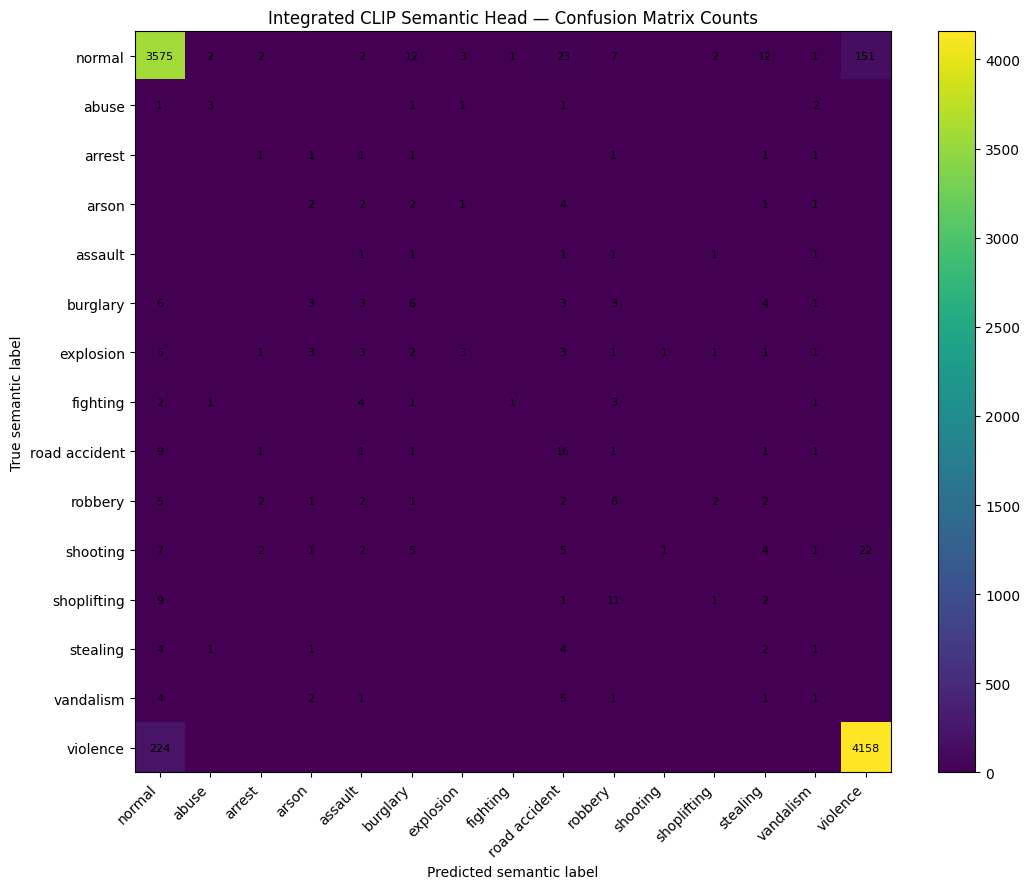

Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/integrated_clip_semantic_confusion_matrix_normalized.png


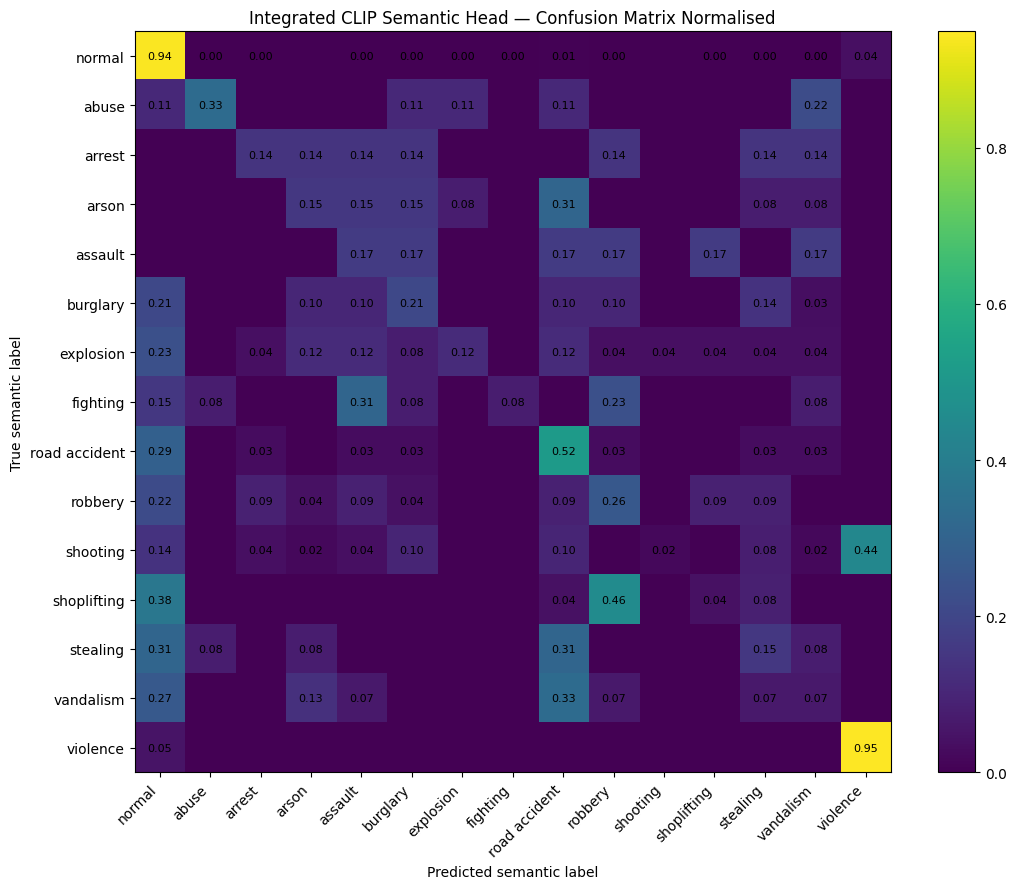

Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/integrated_clip_semantic_classification_report.csv


,precision,recall,f1-score,support
normal,0.9281,0.9425,0.9353,3793.0000
abuse,0.4286,0.3333,0.3750,9.0000
arrest,0.1111,0.1429,0.1250,7.0000
arson,0.1429,0.1538,0.1481,13.0000
assault,0.0455,0.1667,0.0714,6.0000
burglary,0.1818,0.2069,0.1935,29.0000
explosion,0.3750,0.1154,0.1765,26.0000
fighting,0.5000,0.0769,0.1333,13.0000
road accident,0.2353,0.5161,0.3232,31.0000
robbery,0.1714,0.2609,0.2069,23.0000


Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/integrated_clip_binary_confusion_matrix_counts.csv


,pred_normal,pred_anomaly
true_normal,3575,218
true_anomaly,277,4364


Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/integrated_clip_binary_confusion_matrix_counts.png


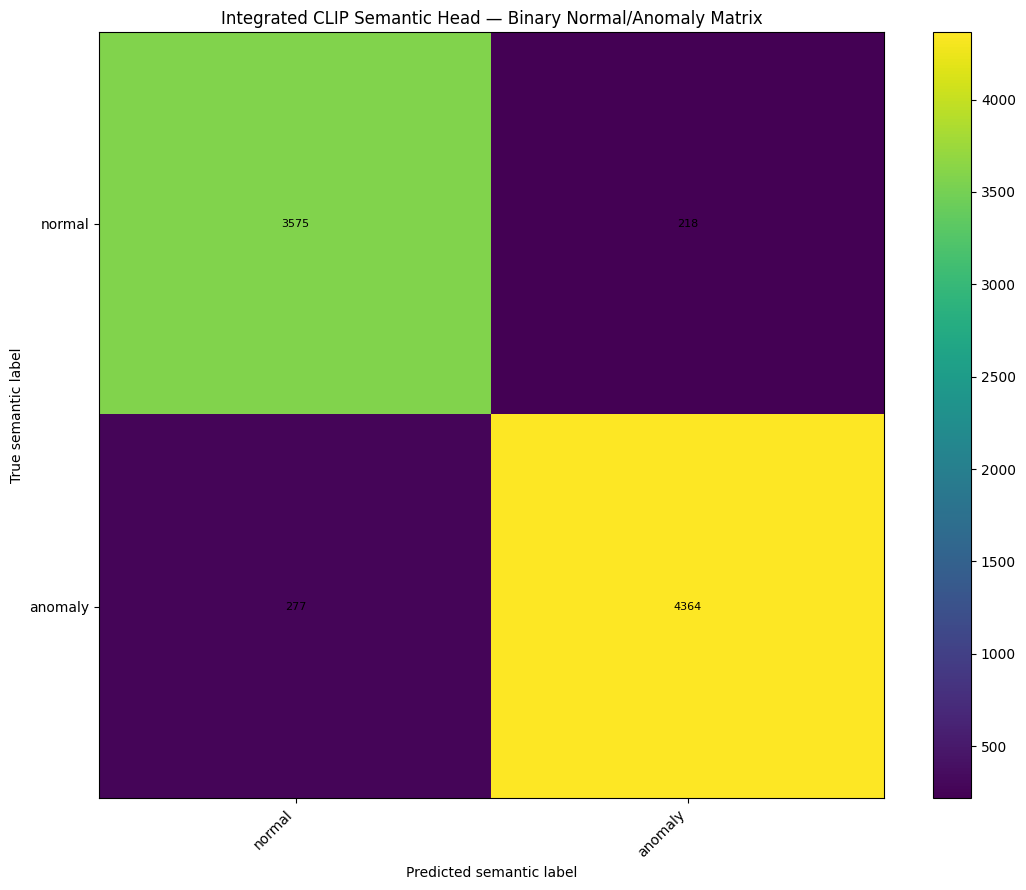

Binary semantic accuracy: 0.9413
Binary semantic F1: 0.9463


In [18]:

# INTEGRATED CLIP SEMANTIC CONFUSION MATRICES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score


if "integrated_clip_pred_df" not in globals():
    integrated_clip_pred_df = pd.read_csv(RESULTS_DIR / "integrated_clip_semantic_predictions.csv")

if "integrated_text_labels" not in globals():
    try:
        _, integrated_ckpt, integrated_text_labels = load_integrated_clip_semantic_model()
    except Exception:
        integrated_text_labels = sorted(
            set(integrated_clip_pred_df["true_semantic_label"].astype(str).str.lower()).union(
                set(integrated_clip_pred_df["predicted_semantic_label"].astype(str).str.lower())
            )
        )

df_iclip = integrated_clip_pred_df.copy()

y_true = df_iclip["true_semantic_label"].astype(str).str.lower()
y_pred = df_iclip["predicted_semantic_label"].astype(str).str.lower()

label_order = [str(x).lower() for x in integrated_text_labels]

# Keep only labels present in the outputs.
present = set(y_true.unique()).union(set(y_pred.unique()))
label_order = [x for x in label_order if x in present]

cm = confusion_matrix(y_true, y_pred, labels=label_order)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{x}" for x in label_order],
    columns=[f"pred_{x}" for x in label_order],
)

cm_path = RESULTS_DIR / "integrated_clip_semantic_confusion_matrix_counts.csv"
cm_df.to_csv(cm_path)

print("Saved:", cm_path)
display(cm_df)


# Normalised by true class.
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0,
)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"true_{x}" for x in label_order],
    columns=[f"pred_{x}" for x in label_order],
)

cm_norm_path = RESULTS_DIR / "integrated_clip_semantic_confusion_matrix_normalized.csv"
cm_norm_df.to_csv(cm_norm_path)

print("Saved:", cm_norm_path)
display(cm_norm_df.round(3))


def plot_cm(cm_values, labels, title, save_name, is_norm=False):
    fig, ax = plt.subplots(figsize=(11, 9))

    im = ax.imshow(cm_values, aspect="auto")
    fig.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted semantic label")
    ax.set_ylabel("True semantic label")
    ax.set_title(title)

    for i in range(cm_values.shape[0]):
        for j in range(cm_values.shape[1]):
            val = cm_values[i, j]
            if is_norm:
                txt = f"{val:.2f}" if val > 0 else ""
            else:
                txt = f"{int(val)}" if int(val) > 0 else ""

            if txt:
                ax.text(j, i, txt, ha="center", va="center", fontsize=8)

    plt.tight_layout()
    save_fig(save_name, fig=fig)
    plt.show()


plot_cm(
    cm,
    label_order,
    "Integrated CLIP Semantic Head — Confusion Matrix Counts",
    "integrated_clip_semantic_confusion_matrix_counts",
    is_norm=False,
)

plot_cm(
    cm_norm,
    label_order,
    "Integrated CLIP Semantic Head — Confusion Matrix Normalised",
    "integrated_clip_semantic_confusion_matrix_normalized",
    is_norm=True,
)


report = classification_report(
    y_true,
    y_pred,
    labels=label_order,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report).T

report_path = RESULTS_DIR / "integrated_clip_semantic_classification_report.csv"
report_df.to_csv(report_path)

print("Saved:", report_path)
display(report_df.round(4))


# Binary normal/anomaly from semantic output.
df_iclip["true_binary_from_text"] = (df_iclip["true_semantic_label"].str.lower() != "normal").astype(int)
df_iclip["pred_binary_from_text"] = (df_iclip["predicted_semantic_label"].str.lower() != "normal").astype(int)

cm_bin = confusion_matrix(
    df_iclip["true_binary_from_text"],
    df_iclip["pred_binary_from_text"],
    labels=[0, 1],
)

cm_bin_df = pd.DataFrame(
    cm_bin,
    index=["true_normal", "true_anomaly"],
    columns=["pred_normal", "pred_anomaly"],
)

cm_bin_path = RESULTS_DIR / "integrated_clip_binary_confusion_matrix_counts.csv"
cm_bin_df.to_csv(cm_bin_path)

print("Saved:", cm_bin_path)
display(cm_bin_df)

plot_cm(
    cm_bin,
    ["normal", "anomaly"],
    "Integrated CLIP Semantic Head — Binary Normal/Anomaly Matrix",
    "integrated_clip_binary_confusion_matrix_counts",
    is_norm=False,
)

binary_acc = accuracy_score(df_iclip["true_binary_from_text"], df_iclip["pred_binary_from_text"])
binary_f1 = f1_score(df_iclip["true_binary_from_text"], df_iclip["pred_binary_from_text"], zero_division=0)

print("Binary semantic accuracy:", round(float(binary_acc), 4))
print("Binary semantic F1:", round(float(binary_f1), 4))


# 16. Precision-Recall curves and post-feature runtime summary

This section generates validation Precision-Recall curves for each trained binary MIL model using the final top-k pooling setup.

For each model, the cell:

1. loads the trained checkpoint;
2. collects validation video-level anomaly scores;
3. plots the Precision-Recall curve;
4. records Average Precision;
5. measures post-feature inference time per video bag.

The runtime measurement reflects only the MIL model forward pass on already-extracted feature bags. It does not include raw video decoding, frame sampling or R(2+1)D/I3D feature extraction.

The generated PR curves and runtime table are used for report figures and efficiency discussion.


Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/pr_curve_val_baseline_mil.png


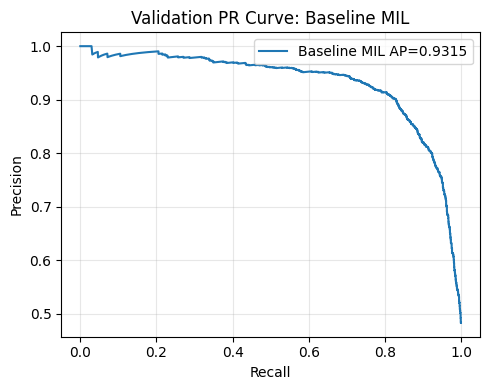

Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/pr_curve_val_attention_mil.png


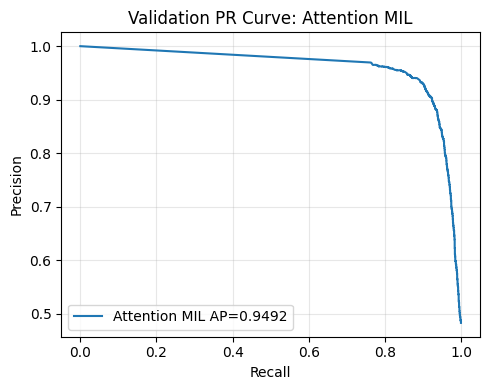

Saved: /scratch/VAD/artifacts/metadata/pr_runtime_summary.csv


,model_key,model_name,val_ap_topk,num_parameters,trainable_parameters,inference_ms_per_bag_post_feature_only
0,baseline_mil,Baseline MIL,0.931472,263169,263169,0.034136
1,attention_mil,Attention MIL,0.949158,1743873,1743873,0.338478


In [19]:

# PRECISION-RECALL CURVES + RUNTIME SUMMARY FOR ALL MODELS

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import torch

TOPK_K = int(CFG.get("topk_k", 4))

pr_rows = []

for spec in MODEL_SPECS:
    try:
        model, ckpt = load_model_from_spec(spec)
    except Exception as e:
        print(f"PR/runtime skipped for {spec['model_name']}: {e}")
        continue

    scores, labels = collect_video_scores_mil(
        model,
        val_loader,
        pooling="topk",
        topk_k=TOPK_K,
    )

    if len(np.unique(labels)) < 2:
        print(f"{spec['model_name']}: skipped PR curve because validation has one class only.")
        continue

    precision, recall, _ = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)

    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label=f"{spec['model_name']} AP={ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Validation PR Curve: {spec['model_name']}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(f"pr_curve_val_{spec['model_key']}")
    plt.show()

    n_params, n_trainable = count_model_parameters(model)

    dummy = torch.randn(1, MIL_DUMMY_T, MIL_INPUT_DIM, device=device)
    dummy_len = torch.tensor([MIL_DUMMY_T], device=device)

    for _ in range(3):
        _ = forward_model(model, dummy, dummy_len)

    if device.type == "cuda":
        torch.cuda.synchronize()

    reps = 30
    t0 = time.perf_counter()

    for _ in range(reps):
        _ = forward_model(model, dummy, dummy_len)

    if device.type == "cuda":
        torch.cuda.synchronize()

    ms = (time.perf_counter() - t0) / reps * 1000

    pr_rows.append(
        {
            "model_key": spec["model_key"],
            "model_name": spec["model_name"],
            "val_ap_topk": float(ap),
            "num_parameters": n_params,
            "trainable_parameters": n_trainable,
            "inference_ms_per_bag_post_feature_only": ms,
        }
    )

pr_runtime_df = pd.DataFrame(pr_rows)
pr_runtime_path = METADATA_DIR / "pr_runtime_summary.csv"
pr_runtime_df.to_csv(pr_runtime_path, index=False)

print("Saved:", pr_runtime_path)
display(pr_runtime_df)

# 17. Segment-level anomaly score curves

This section visualises how a trained MIL model scores individual temporal segments within validation videos.

For each video, the model produces segment-level anomaly scores:

```text
segment logits → sigmoid scores → top-k video score
```

The plots show:

- temporal segment index;
- segment-level anomaly score;
- binary ground-truth video label;
- pooled top-k video score.

These curves provide qualitative evidence of how the model distributes anomaly scores across time.

Because the project is weakly supervised, these plots should be interpreted as segment-score visualisations rather than exact frame-level anomaly localisation.


GENERATING SEGMENT-LEVEL ANOMALY SCORE CURVES
Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/anomaly_score_curves_val_attention_mil.png


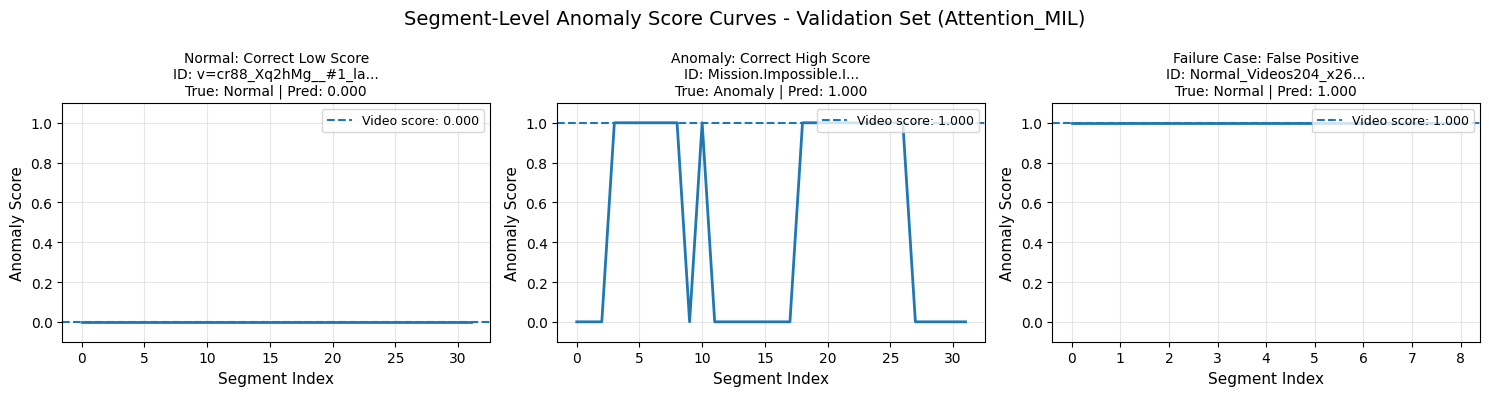


----------------------------------------------------------------------
INTERPRETATION (Attention_MIL):
- Left: Normal video correctly gets low scores across all segments
- Middle: Anomaly video correctly shows high scores during anomalous segments
- Right: Failure case - model misclassifies (FP or FN)

Failure case analysis:
  FP (Normal predicted as Anomaly): Normal_Videos204_x264 - score=1.000
  FN (Anomaly predicted as Normal): wangted.2008__#0-39-22_0-39-34_label_B2-0-0__0 - score=0.000

Failure-case bank (threshold = 0.0 ):
  False positives (normal predicted high): 5 - ['Normal_Videos204_x264', 'Normal_Videos292_x264', 'Normal_Videos743_x264', 'Normal_Videos792_x264', 'Normal_Videos921_x264']
  False negatives (anomaly predicted low): 5 - ['Robbery123_x264', 'Vandalism004_x264', 'Stealing054_x264', 'Robbery125_x264', 'Shoplifting053_x264']
Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_

,idx,clip_id,class,label,video_score,num_segments,score_min,score_max,score_mean,score_std
3058,3058,v=cr88_Xq2hMg__#1_label_A__4,unknown,0,1.301073e-12,32,1.198815e-12,1.326352e-12,1.250422e-12,2.804270e-14
2681,2681,Before.Sunset.2004__#00-11-00_00-15-08_label_A__4,unknown,0,1.315005e-12,32,1.164229e-12,1.339301e-12,1.240332e-12,4.591128e-14
1908,1908,v=PK-Tn6R8f0s__#1_label_A__1,unknown,0,1.315456e-12,32,1.208217e-12,1.321569e-12,1.268144e-12,2.971328e-14
325,325,Kill.Bill.Vol.2.2004__#0-12-30_0-14-20_label_A__4,unknown,0,1.319743e-12,32,1.163270e-12,1.335335e-12,1.251501e-12,4.116059e-14
1274,1274,v=H9Y5_X1sEEA__#00-51-00_00-54-00_label_A__0,unknown,0,1.319853e-12,32,1.162062e-12,1.340730e-12,1.251622e-12,4.295671e-14
2640,2640,v=H9Y5_X1sEEA__#00-51-00_00-54-00_label_A__3,unknown,0,1.324074e-12,32,1.179814e-12,1.335554e-12,1.261447e-12,4.209134e-14
3594,3594,Good.Will.Hunting.1997__#01-33-18_01-36-11_lab...,unknown,0,1.331275e-12,32,1.184473e-12,1.333958e-12,1.287624e-12,3.447056e-14
3263,3263,v=c0GlCjZbVzk__#1_label_A__0,unknown,0,1.331901e-12,32,1.217958e-12,1.349584e-12,1.280892e-12,3.213741e-14
337,337,v=H9Y5_X1sEEA__#00-06-00_00-09-00_label_A__3,unknown,0,1.333375e-12,32,1.232068e-12,1.357958e-12,1.283540e-12,2.904822e-14
3411,3411,v=bpXcG9Nfvos__#1_label_A__3,unknown,0,1.334269e-12,32,1.153148e-12,1.345285e-12,1.253272e-12,5.238856e-14


,idx,clip_id,class,label,video_score,num_segments,score_min,score_max,score_mean,score_std
31,31,RoadAccidents119_x264,unknown,1,1.0,21,1.000000e+00,1.0,1.000000,0.000000e+00
28,28,Vandalism001_x264,unknown,1,1.0,17,4.887385e-07,1.0,0.815513,3.776351e-01
26,26,Fighting004_x264,unknown,1,1.0,208,1.000000e+00,1.0,1.000000,0.000000e+00
25,25,Burglary019_x264,unknown,1,1.0,35,9.788505e-05,1.0,0.956440,1.795104e-01
23,23,Robbery049_x264,unknown,1,1.0,23,1.132071e-11,1.0,0.826083,3.790239e-01
20,20,Fighting013_x264,unknown,1,1.0,17,1.000000e+00,1.0,1.000000,0.000000e+00
19,19,Shooting039_x264,unknown,1,1.0,9,9.999998e-01,1.0,1.000000,7.947286e-08
18,18,Assault003_x264,unknown,1,1.0,54,1.000000e+00,1.0,1.000000,0.000000e+00
17,17,Robbery124_x264,unknown,1,1.0,118,8.672543e-11,1.0,0.483432,4.807933e-01
4143,4143,Yellow.Sea.2010__#00-42-00_00-42-56_label_B1-0...,unknown,1,1.0,32,1.457018e-12,1.0,0.575640,4.837653e-01


In [20]:

# Plots segment-level scores with clear identification for trained model.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

def plot_anomaly_score_curves(model, manifest_df, model_name="Model"):
    model.eval()

    norm_stats = None
    norm_stats_path = METADATA_DIR / "bag_norm_stats.npz"
    if norm_stats_path.exists():
        stats = np.load(norm_stats_path)
        norm_stats = (stats["mean"], stats["std"])

    # Collect video data
    video_data = []
    for idx in range(len(manifest_df)):
        row = manifest_df.iloc[idx]
        bag = np.load(row.feature_path).astype(np.float32)

        if norm_stats is not None:
            bag = (bag - norm_stats[0]) / norm_stats[1]

        x = torch.tensor(bag).unsqueeze(0).float().to(device)

        with torch.no_grad():
            out = model(x)
            logits = (out[0] if isinstance(out, tuple) else out).cpu().numpy()[0]

        scores = 1.0 / (1.0 + np.exp(-logits))  # sigmoid
        video_score = float(np.mean(np.sort(scores)[-max(1, len(scores) // 8):]))

        video_data.append({
            "idx": idx,
            "clip_id": row["clip_id"],
            "class": row["class_name"] if "class_name" in row else "unknown",
            "label": int(row["label"]),
            "video_score": video_score,
            "segment_scores": scores,
            "true_label": "Anomaly" if row["label"] == 1 else "Normal",
        })

    normal_videos = [v for v in video_data if v["label"] == 0]
    anomaly_videos = [v for v in video_data if v["label"] == 1]

    if not normal_videos or not anomaly_videos:
        print(f"{model_name}: cannot plot examples (need both normal and anomaly videos).")
        return None

    def score_std(v):
        return float(np.std(v["segment_scores"]))


    def is_not_saturated(v):
        scores = np.asarray(v["segment_scores"])
        return not (np.all(scores > 0.99) or np.all(scores < 0.01))


    # Correct normal: low score normal video
    normal_example = min(normal_videos, key=lambda x: x["video_score"])

    # Correct anomaly: prefer high score but visible temporal variation
    non_saturated_anomalies = [v for v in anomaly_videos if is_not_saturated(v)]

    if non_saturated_anomalies:
        anomaly_example = max(
            non_saturated_anomalies,
            key=lambda x: (x["video_score"], score_std(x)),
        )
    else:
        anomaly_example = max(anomaly_videos, key=lambda x: x["video_score"])

    # Failure candidates
    fp_example = max(normal_videos, key=lambda x: x["video_score"])
    fn_example = min(anomaly_videos, key=lambda x: x["video_score"])

    if fp_example["video_score"] >= 0.5:
        failure_example = fp_example
        failure_title = "Failure Case: False Positive"
    else:
        failure_example = fn_example
        failure_title = "Failure Case: False Negative"

    examples = [
        (normal_example, "Normal: Correct Low Score"),
        (anomaly_example, "Anomaly: Correct High Score"),
        (failure_example, failure_title),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, (ex, title) in zip(axes, examples):
        ax.plot(ex["segment_scores"], linewidth=2)
        ax.axhline(
            y=ex["video_score"],
            linestyle="--",
            label=f'Video score: {ex["video_score"]:.3f}'
        )
        ax.set_xlabel("Segment Index", fontsize=11)
        ax.set_ylabel("Anomaly Score", fontsize=11)
        clip_short = ex["clip_id"][:20] + "..." if len(ex["clip_id"]) > 20 else ex["clip_id"]
        ax.set_title(
            f"{title}\nID: {clip_short}\nTrue: {ex['true_label']} | Pred: {ex['video_score']:.3f}",
            fontsize=10
        )
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([-0.1, 1.1])

    plt.suptitle(f"Segment-Level Anomaly Score Curves - Validation Set ({model_name})", fontsize=14)
    plt.tight_layout()
    save_fig(f"anomaly_score_curves_val_{model_name}", fig=fig)
    plt.show()

    print("\n" + "-" * 70)
    print(f"INTERPRETATION ({model_name}):")
    print("- Left: Normal video correctly gets low scores across all segments")
    print("- Middle: Anomaly video correctly shows high scores during anomalous segments")
    print("- Right: Failure case - model misclassifies (FP or FN)")
    print("\nFailure case analysis:")
    print(f"  FP (Normal predicted as Anomaly): {fp_example['clip_id']} - score={fp_example['video_score']:.3f}")
    print(f"  FN (Anomaly predicted as Normal): {fn_example['clip_id']} - score={fn_example['video_score']:.3f}")

    # Failure-case bank
    video_scores_per_row = [
        (v["idx"], v["clip_id"], v["label"], v["video_score"], v["segment_scores"])
        for v in video_data
    ]

    if video_scores_per_row:
        threshold = np.median([vs for _, _, _, vs, _ in video_scores_per_row])
        fp_list = [(cid, lab, vs) for _, cid, lab, vs, _ in video_scores_per_row if lab == 0 and vs >= threshold][:5]
        fn_list = [(cid, lab, vs) for _, cid, lab, vs, _ in video_scores_per_row if lab == 1 and vs < threshold][:5]

        print("\nFailure-case bank (threshold =", round(threshold, 3), "):")
        print("  False positives (normal predicted high):", len(fp_list), "-", [x[0][:30] for x in fp_list])
        print("  False negatives (anomaly predicted low):", len(fn_list), "-", [x[0][:30] for x in fn_list])

    return video_data

# ============================================================================
# RUN SEGMENT-LEVEL SCORE CURVES FOR FINAL ATTENTION MODEL
# ============================================================================

print("=" * 80)
print("GENERATING SEGMENT-LEVEL ANOMALY SCORE CURVES")
print("=" * 80)

attention_spec = [s for s in MODEL_SPECS if s["model_key"] == "attention_mil"][0]
attention_model_for_curves, _ = load_model_from_spec(attention_spec)

attention_video_data = plot_anomaly_score_curves(
    attention_model_for_curves,
    val_manifest_df,
    model_name="Attention_MIL",
)

if attention_video_data is not None:
    curve_rows = []

    for v in attention_video_data:
        curve_rows.append(
            {
                "idx": v["idx"],
                "clip_id": v["clip_id"],
                "class": v["class"],
                "label": v["label"],
                "video_score": v["video_score"],
                "num_segments": len(v["segment_scores"]),
                "score_min": float(np.min(v["segment_scores"])),
                "score_max": float(np.max(v["segment_scores"])),
                "score_mean": float(np.mean(v["segment_scores"])),
                "score_std": float(np.std(v["segment_scores"])),
            }
        )

    curve_df = pd.DataFrame(curve_rows)
    curve_path = RESULTS_DIR / "attention_segment_score_curve_diagnostics.csv"
    curve_df.to_csv(curve_path, index=False)

    print("Saved:", curve_path)
    display(curve_df.sort_values("video_score").head(10))
    display(curve_df.sort_values("video_score").tail(10))


# 18. UMAP / t-SNE feature visualisation

This section visualises validation videos in a two-dimensional embedding space using UMAP or t-SNE.

The notebook produces different embedding views, including:

```text
mean-pooled video features
normalised mean-pooled video features
model-guided top-k segment features
raw video-mean feature embeddings
```

Each point represents one validation video or clip. The colour indicates the binary normal/anomaly label.

These plots are qualitative visualisations. They help show whether normal and anomalous samples form partially separable regions, but they are not used as the main quantitative metric.

Overlap between normal and anomalous points is expected because video-level mean features can dilute short anomalies.


I0000 00:00:1780080688.263129  663574 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780080688.289286  663574 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780080689.086939  663574 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/scratch/VAD/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state

Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/embedding_umap_mean_features.png


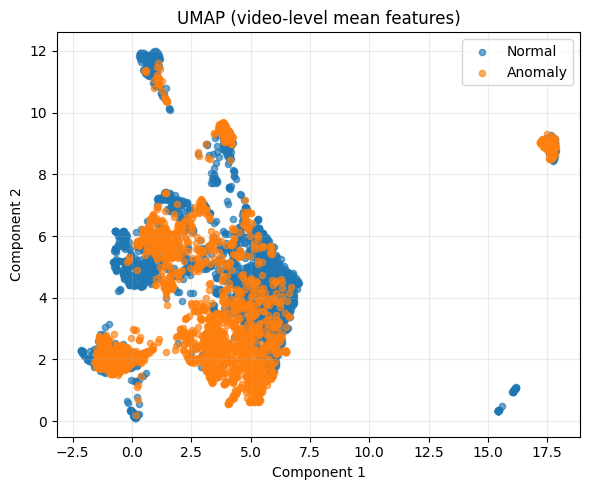

/scratch/VAD/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/embedding_umap_topk_features.png


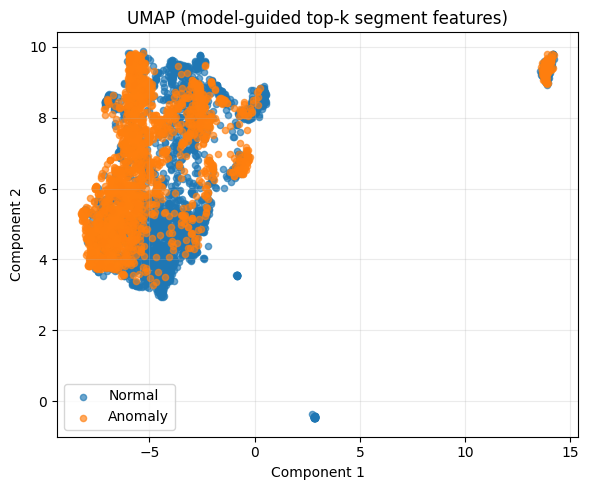

Interpretation note: overlap is expected because weak video-level labels and mean pooling can dilute short temporal anomalies.


In [21]:
# ============================================================================
# UMAP / t-SNE FEATURE VISUALISATION
# ============================================================================
# Produces:
# 1. Mean-pooled feature embedding
# 2. Model-guided top-k segment feature embedding

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False


def reduce_2d(X, title_prefix):
    if len(X) < 3:
        raise ValueError("Too few samples for 2D embedding.")

    if HAS_UMAP:
        reducer = umap.UMAP(
            n_components=2,
            random_state=SEED,
            n_neighbors=min(15, len(X) - 1),
            min_dist=0.1,
        )
        emb = reducer.fit_transform(X)
        title = f"UMAP ({title_prefix})"
    else:
        emb = TSNE(
            n_components=2,
            random_state=SEED,
            perplexity=min(30, max(2, len(X) // 10)),
            init="pca",
            learning_rate="auto",
        ).fit_transform(X)
        title = f"t-SNE ({title_prefix})"

    return emb, title


def load_norm_stats():
    norm_path = METADATA_DIR / "bag_norm_stats.npz"
    if norm_path.exists():
        d = np.load(norm_path)
        return d["mean"], d["std"]
    return None


norm_stats = load_norm_stats()

attention_spec = [s for s in MODEL_SPECS if s["model_key"] == "attention_mil"][0]
attention_model_umap, _ = load_model_from_spec(attention_spec)
attention_model_umap.eval()

TOPK_K = int(CFG.get("topk_k", 4))

mean_feats = []
topk_feats = []
labels = []

for _, row in val_manifest_df.iterrows():
    bag = np.load(row.feature_path).astype(np.float32)

    if norm_stats is not None:
        mean, std = norm_stats
        bag_norm = (bag - mean) / std
    else:
        bag_norm = bag

    # Mean pooled feature
    mean_feats.append(bag_norm.mean(axis=0))

    # Model-guided top-k segment feature
    x = torch.tensor(bag_norm).unsqueeze(0).float().to(device)
    lengths = torch.tensor([x.shape[1]], device=device)

    with torch.no_grad():
        logits = forward_model(attention_model_umap, x, lengths)
        scores = torch.sigmoid(logits).detach().cpu().numpy()[0]

    k = min(max(1, TOPK_K), len(scores))
    topk_idx = np.argsort(scores)[-k:]
    topk_feats.append(bag_norm[topk_idx].mean(axis=0))

    labels.append(int(row["label"]))

X_mean = np.stack(mean_feats).astype(np.float32)
X_topk = np.stack(topk_feats).astype(np.float32)
y = np.asarray(labels)

embedding_outputs = [
    (X_mean, "video-level mean features", "embedding_umap_mean_features"),
    (X_topk, "model-guided top-k segment features", "embedding_umap_topk_features"),
]

for X_vis, title_prefix, save_name in embedding_outputs:
    emb, title = reduce_2d(X_vis, title_prefix)

    plt.figure(figsize=(6, 5))
    plt.scatter(
        emb[y == 0, 0],
        emb[y == 0, 1],
        label="Normal",
        alpha=0.65,
        s=20,
    )
    plt.scatter(
        emb[y == 1, 0],
        emb[y == 1, 1],
        label="Anomaly",
        alpha=0.65,
        s=20,
    )
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    save_fig(save_name)
    plt.show()

print(
    "Interpretation note: overlap is expected because weak video-level labels "
    "and mean pooling can dilute short temporal anomalies."
)


Using train-fitted bag normalisation for UMAP.


/scratch/VAD/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/embedding_normalised_video_level_mean_features.png


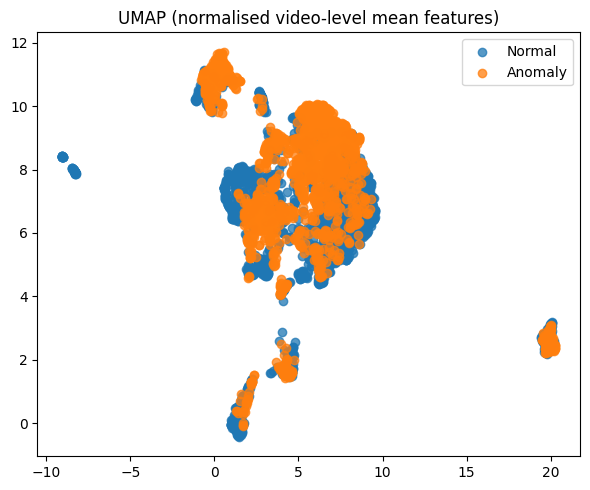

In [22]:
# UMAP or t-SNE: video-level mean features with the same normalisation used in training
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

try:
    import umap
    reducer = umap.UMAP(
        n_components=2,
        random_state=SEED,
        n_neighbors=min(15, len(val_manifest_df) - 1),
        min_dist=0.1,
        metric="cosine",
    )
except ImportError:
    reducer = None

# Load train-fitted normalisation stats if available
norm_stats = None
norm_path = METADATA_DIR / "bag_norm_stats.npz"
if norm_path.exists():
    stats = np.load(norm_path)
    norm_stats = (stats["mean"], stats["std"])
    print("Using train-fitted bag normalisation for UMAP.")

feats_list, lab_list = [], []

for _, row in val_manifest_df.iterrows():
    bag = np.load(row.feature_path).astype(np.float32)

    if norm_stats is not None:
        mean, std = norm_stats
        bag = (bag - mean) / std

    # One vector per video
    video_feat = bag.mean(axis=0)

    feats_list.append(video_feat)
    lab_list.append(int(row.label))

X = np.stack(feats_list)
y = np.array(lab_list)

if len(X) < 3:
    print("Too few val samples for UMAP/t-SNE.")
else:
    if reducer is not None:
        emb = reducer.fit_transform(X)
        title = "UMAP (normalised video-level mean features)"
    else:
        emb = TSNE(
            n_components=2,
            random_state=SEED,
            perplexity=min(5, len(X) - 1),
            metric="cosine",
        ).fit_transform(X)
        title = "t-SNE (normalised video-level mean features)"

    plt.figure(figsize=(6, 5))
    plt.scatter(emb[y == 0, 0], emb[y == 0, 1], label="Normal", alpha=0.75)
    plt.scatter(emb[y == 1, 0], emb[y == 1, 1], label="Anomaly", alpha=0.75)
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    save_fig("embedding_normalised_video_level_mean_features")
    plt.show()

Running raw video-mean feature UMAP on split: val
Number of videos/clips: 4144
Using raw precomputed features without model normalisation.
Feature matrix shape: (4144, 512)
Labels shape: (4144,)
Normal videos: 2143
Anomaly videos: 2001


/scratch/VAD/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved embedding CSV: /scratch/VAD/artifacts/metadata/umap_val_raw_video_mean_features.csv
Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/umap_val_raw_video_mean_features.png


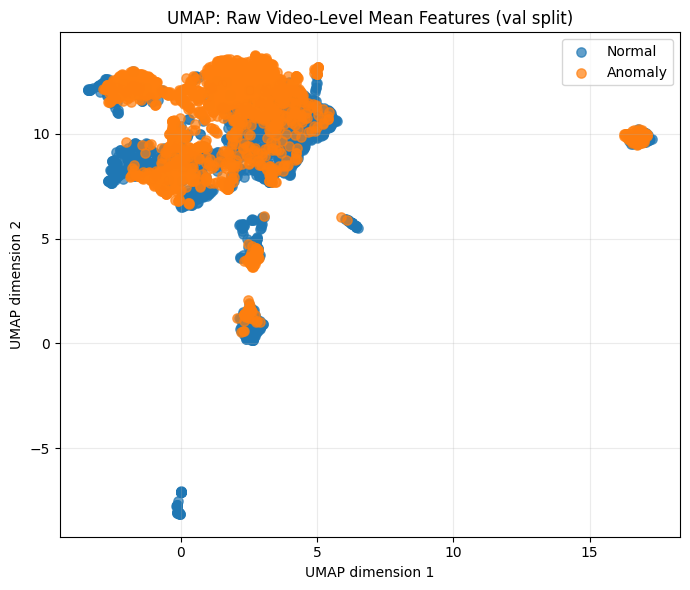

In [23]:
# ============================================================================
# RAW VIDEO-MEAN FEATURE UMAP / t-SNE
# ============================================================================
# Purpose:
# - One point = one video/clip
# - Feature for each point = mean of all segment features in that video
# - This is expected to look scattered/mixed because anomalous videos often
#   contain many normal segments, so video-level averaging dilutes anomalies.
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE

# ---------------------------------------------------------------------------
# Choose split to visualise
# ---------------------------------------------------------------------------
SPLIT_FOR_UMAP = "val"   # "train", "val", or "test"

if SPLIT_FOR_UMAP == "train":
    umap_manifest_df = train_manifest_df.copy()
elif SPLIT_FOR_UMAP == "val":
    umap_manifest_df = val_manifest_df.copy()
elif SPLIT_FOR_UMAP == "test":
    umap_manifest_df = test_manifest_df.copy()
else:
    raise ValueError("SPLIT_FOR_UMAP must be 'train', 'val', or 'test'.")

print(f"Running raw video-mean feature UMAP on split: {SPLIT_FOR_UMAP}")
print("Number of videos/clips:", len(umap_manifest_df))

# ---------------------------------------------------------------------------
# Optional: keep False for truly raw/precomputed feature UMAP
# ---------------------------------------------------------------------------
APPLY_TRAIN_NORMALISATION = False

norm_stats = None
norm_path = METADATA_DIR / "bag_norm_stats.npz"

if APPLY_TRAIN_NORMALISATION and norm_path.exists():
    stats = np.load(norm_path)
    norm_stats = (stats["mean"], stats["std"])
    print("Using train-fitted bag normalisation.")
elif APPLY_TRAIN_NORMALISATION:
    print("Normalisation requested, but bag_norm_stats.npz was not found. Using raw features.")
else:
    print("Using raw precomputed features without model normalisation.")

# ---------------------------------------------------------------------------
# Build one vector per video by averaging all temporal segment features
# ---------------------------------------------------------------------------
video_features = []
video_labels = []
clip_ids = []

for _, row in umap_manifest_df.iterrows():
    feature_path = Path(row["feature_path"])

    if not feature_path.exists():
        print(f"Skipping missing feature file: {feature_path}")
        continue

    bag = np.load(feature_path).astype(np.float32)  # shape: [num_segments, feature_dim]

    if bag.ndim != 2:
        print(f"Skipping invalid feature shape {bag.shape}: {feature_path}")
        continue

    if norm_stats is not None:
        mean, std = norm_stats
        bag = (bag - mean) / std

    # This is the key line:
    # average all segment features into one video-level feature vector
    video_mean_feature = bag.mean(axis=0)

    video_features.append(video_mean_feature)
    video_labels.append(int(row["label"]))

    if "clip_id" in row:
        clip_ids.append(str(row["clip_id"]))
    elif "video_id" in row:
        clip_ids.append(str(row["video_id"]))
    else:
        clip_ids.append(feature_path.stem)

X = np.stack(video_features)
y = np.array(video_labels)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Normal videos:", int((y == 0).sum()))
print("Anomaly videos:", int((y == 1).sum()))

if len(X) < 3:
    raise ValueError("Too few samples for UMAP/t-SNE visualisation.")

# ---------------------------------------------------------------------------
# Run UMAP if available, otherwise fallback to t-SNE
# ---------------------------------------------------------------------------
try:
    import umap

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(15, len(X) - 1),
        min_dist=0.1,
        metric="cosine",
        random_state=SEED,
    )

    embedding = reducer.fit_transform(X)
    method_name = "UMAP"

except ImportError:
    print("umap-learn not installed. Falling back to t-SNE.")

    reducer = TSNE(
        n_components=2,
        perplexity=min(30, max(2, len(X) // 3)),
        metric="cosine",
        init="pca",
        learning_rate="auto",
        random_state=SEED,
    )

    embedding = reducer.fit_transform(X)
    method_name = "t-SNE"

# ---------------------------------------------------------------------------
# Save embedding values for the report / appendix
# ---------------------------------------------------------------------------
embedding_df = pd.DataFrame({
    "clip_id": clip_ids,
    "label": y,
    "label_name": np.where(y == 0, "Normal", "Anomaly"),
    "dim1": embedding[:, 0],
    "dim2": embedding[:, 1],
})

embedding_csv_path = METADATA_DIR / f"{method_name.lower()}_{SPLIT_FOR_UMAP}_raw_video_mean_features.csv"
embedding_df.to_csv(embedding_csv_path, index=False)

print(f"Saved embedding CSV: {embedding_csv_path}")

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
plt.figure(figsize=(7, 6))

plt.scatter(
    embedding[y == 0, 0],
    embedding[y == 0, 1],
    label="Normal",
    alpha=0.70,
    s=45,
)

plt.scatter(
    embedding[y == 1, 0],
    embedding[y == 1, 1],
    label="Anomaly",
    alpha=0.70,
    s=45,
)

plt.title(f"{method_name}: Raw Video-Level Mean Features ({SPLIT_FOR_UMAP} split)")
plt.xlabel(f"{method_name} dimension 1")
plt.ylabel(f"{method_name} dimension 2")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

# Save figure using notebook's save_fig() if available
fig_name = f"{method_name.lower()}_{SPLIT_FOR_UMAP}_raw_video_mean_features"

if "save_fig" in globals():
    save_fig(fig_name)
else:
    fallback_path = METADATA_DIR / f"{fig_name}.png"
    plt.savefig(fallback_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {fallback_path}")

plt.show()

# 19. Attention heatmap visualisation

This section visualises temporal self-attention weights from the Attention MIL model.

The attention heatmap shows how temporal segments attend to each other:

```text
row = query segment
column = key segment
brighter value = stronger attention
```

The plots are generated for representative examples such as:

```text
normal low-score video
anomalous high-score video
failure case
```

These heatmaps show temporal relationships between segment-level features. They do not show spatial attention over image pixels.



ATTENTION HEATMAP VISUALIZATION
Loading best attention model using MODEL_SPECS...
Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/attention_heatmap_normal_low_score.png


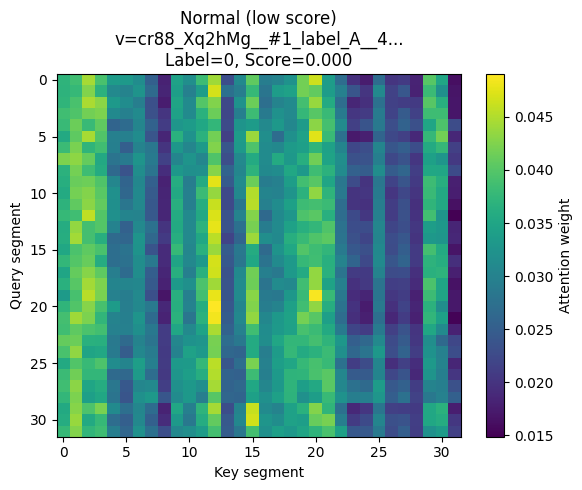

Heatmap interpretation: Normal (low score)
- Diagonal: self-attention (segment attending to itself)
- Off-diagonal: cross-segment attention
- Bright regions: segments that strongly influence each other
- For anomaly: look for attention focused on specific temporal regions

Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/attention_heatmap_anomaly_high_score.png


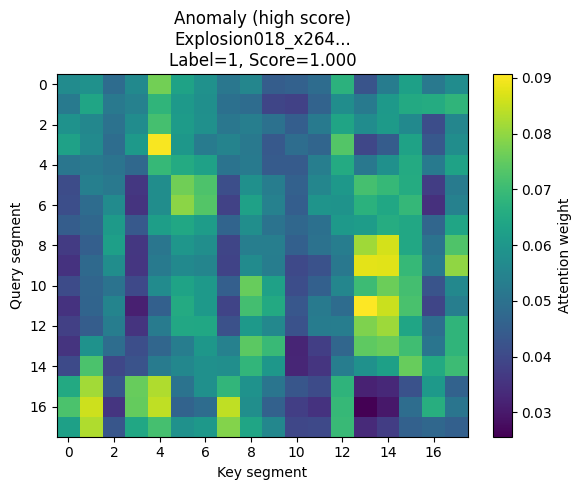

Heatmap interpretation: Anomaly (high score)
- Diagonal: self-attention (segment attending to itself)
- Off-diagonal: cross-segment attention
- Bright regions: segments that strongly influence each other
- For anomaly: look for attention focused on specific temporal regions

Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/attention_heatmap_failure_case.png


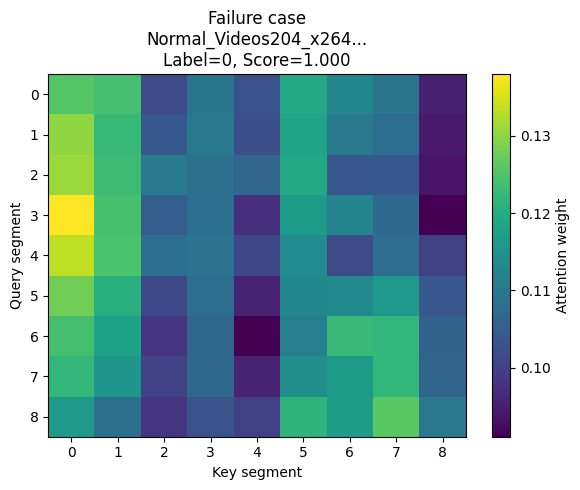

Heatmap interpretation: Failure case
- Diagonal: self-attention (segment attending to itself)
- Off-diagonal: cross-segment attention
- Bright regions: segments that strongly influence each other
- For anomaly: look for attention focused on specific temporal regions



In [24]:
# ATTENTION HEATMAP VISUALIZATION

import matplotlib.pyplot as plt
import numpy as np

def generate_attention_heatmaps(model_to_use, num_samples=3):
    """Generate attention heatmaps for sample videos."""
    if not hasattr(model_to_use, 'return_attention'):
        print("Model doesn't support attention return. Using fallback.")
        return

    model_to_use.eval()
    model_to_use.return_attention = True

    # Get norm stats
    norm_stats = None
    if (METADATA_DIR / "bag_norm_stats.npz").exists():
        stats = np.load(METADATA_DIR / "bag_norm_stats.npz")
        norm_stats = (stats["mean"], stats["std"])

    # Collect samples
    samples = []
    for idx in range(len(val_manifest_df)):
        row = val_manifest_df.iloc[idx]
        bag = np.load(row.feature_path).astype(np.float32)
        if norm_stats:
            bag = (bag - norm_stats[0]) / norm_stats[1]

        x = torch.tensor(bag).unsqueeze(0).float().to(device)
        lens = torch.tensor([bag.shape[0]], device=device)

        with torch.no_grad():
            out = model_to_use(x)

        if isinstance(out, tuple):
            logits, attn_weights = out
            scores = torch.sigmoid(logits).cpu().numpy()[0]
            vid_score = float(np.mean(np.sort(scores)[-max(1, len(scores)//8):]))
            attn = attn_weights[0].cpu().numpy()
            T_valid = min(int(lens[0].item()), attn.shape[0])

            samples.append({
                'clip_id': row['clip_id'],
                'label': int(row['label']),
                'score': vid_score,
                'attn': attn[:T_valid, :T_valid]
            })

    model_to_use.return_attention = False

    if not samples:
        print("No attention samples generated.")
        return

    # Select representative samples
    normals = [s for s in samples if s['label'] == 0]
    anomalies = [s for s in samples if s['label'] == 1]

    selected = []
    if normals:
        selected.append(min(normals, key=lambda x: x['score']))
    if anomalies:
        selected.append(max(anomalies, key=lambda x: x['score']))
    if normals and anomalies:
        fp = max(normals, key=lambda x: x['score'])
        fn = min(anomalies, key=lambda x: x['score'])
        selected.append(fp if fp['score'] > 0.5 else fn)

    titles = ["Normal (low score)", "Anomaly (high score)", "Failure case"]
    for i, sample in enumerate(selected[:3]):
        plt.figure(figsize=(6, 5))
        plt.imshow(sample['attn'], cmap='viridis', aspect='auto')
        plt.colorbar(label='Attention weight')
        plt.title(f"{titles[i]}\n{sample['clip_id'][:30]}...\nLabel={sample['label']}, Score={sample['score']:.3f}")
        plt.xlabel("Key segment")
        plt.ylabel("Query segment")
        plt.tight_layout()
        save_fig(f"attention_heatmap_{titles[i]}")
        plt.show()
        print(f"Heatmap interpretation: {titles[i]}")
        print("- Diagonal: self-attention (segment attending to itself)")
        print("- Off-diagonal: cross-segment attention")
        print("- Bright regions: segments that strongly influence each other")
        print("- For anomaly: look for attention focused on specific temporal regions\n")

# Generate heatmaps using best attention model
print("\n" + "="*60)
print("ATTENTION HEATMAP VISUALIZATION")
print("="*60)

attention_specs = [s for s in MODEL_SPECS if s["model_key"] == "attention_mil"]

if len(attention_specs) == 0:
    print("No attention model spec found. Heatmaps skipped.")
else:
    print("Loading best attention model using MODEL_SPECS...")
    model_attn, _ = load_model_from_spec(attention_specs[0])

    if hasattr(model_attn, "return_attention"):
        generate_attention_heatmaps(model_attn, num_samples=3)
    else:
        print("Loaded attention model does not expose return_attention. Heatmaps skipped.")


# 20. Single-clip inference demo

This section runs one saved feature bag through the trained MIL model and visualises segment-level anomaly scores.

The model produces one anomaly score for each temporal segment. In the submitted configuration, each video is represented using 32 temporal segments.

The plot shows:

- temporal segment index;
- segment-level anomaly score;
- video-level top-k anomaly score;
- binary video-level label.

This is a qualitative inference demo. Since the model is trained with weak video-level labels, the segment scores should be interpreted as predicted high-scoring temporal regions, not ground-truth frame-level anomaly boundaries.


Loading Attention MIL checkpoint from: /scratch/VAD/artifacts/metadata/mil_best_attention.pth
SINGLE-CLIP DEMO
Demo split: val
Demo clip_id: Mission.Impossible.II.2000__#01-36-14_01-37-20_label_B1-G-0__0
Demo label: 1
Raw clip feature shape: (32, 512)
Applied bag normalization from: /scratch/VAD/artifacts/metadata/bag_norm_stats.npz

DIAGNOSTICS
--------------------------------------------------------------------------------
Number of valid segments: 32
Top-k k: 4
Top-k segment indices: [19, 24, 25, 26]
Video-level anomaly score: 1.0

Logits statistics:
  min: -27.3192138671875
  max: 23.028438568115234
  mean: -1.9834954738616943
  std: 24.20499610900879

Score statistics:
  min: 1.3658913410041773e-12
  max: 1.0
  mean: 0.5
  std: 0.5
  first 10 scores: [0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0]
Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/demo_single_

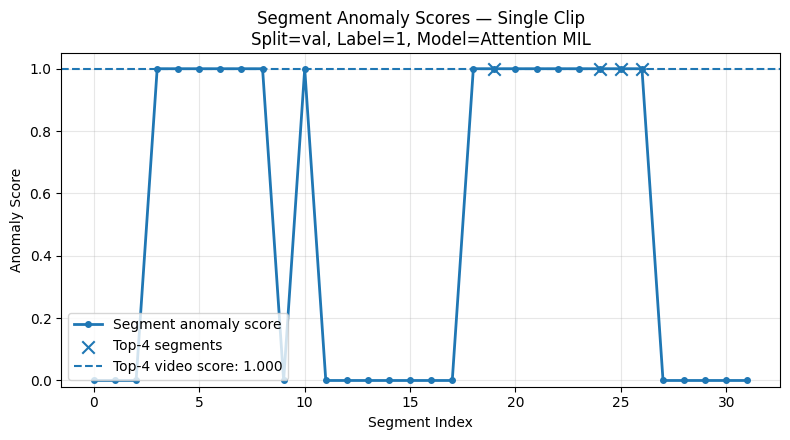

In [25]:
# ============================================================================
# SINGLE-CLIP INFERENCE DEMO — SEGMENT-LEVEL ANOMALY SCORES
# ============================================================================
# Loads one clip's feature bag and plots segment-level anomaly scores.
# Compatible with both old checkpoint format ("model") and new Notebook 4 format
# ("model_state_dict").
#
# Important:
# MIL models are trained with weak video-level labels, so these segment scores
# are predicted anomaly scores, not ground-truth segment labels.

if PHASE_ACTIVE < 2:
    raise RuntimeError("Phase 1 only. Set PHASE_ACTIVE = 2 in Config to run pipeline.")

import matplotlib.pyplot as plt
import numpy as np
import torch


# ---------------------------------------------------------------------------
# Demo settings
# ---------------------------------------------------------------------------
DEMO_USE_ATTENTION = True
DEMO_SPLIT = "val"

# "interesting_anomaly": high-scoring anomaly with visible temporal variation
# "normal": low-scoring normal example
# "failure": highest-scoring normal or lowest-scoring anomaly
DEMO_SELECTION_MODE = "interesting_anomaly"

TOPK_K = int(CFG.get("topk_k", 4))


def _load_demo_model():
    """
    Load demo model from memory if available, otherwise from checkpoint.
    Supports both old and new checkpoint formats.
    """
    if DEMO_USE_ATTENTION:
        m = globals().get("model_attention")
        if m is not None:
            print("Using in-memory attention model.")
            return m

        ckpt = METADATA_DIR / "mil_best_attention.pth"
        cls = MILModelWithAttention
        kwargs = {
            "input_dim": MIL_INPUT_DIM,
            "feature_dim": MIL_INPUT_DIM,
            "hidden_dim": 256,
            "num_heads": 4,
            "dropout": 0.3,
        }
        model_name = "Attention MIL"

    else:
        m = globals().get("model_baseline")
        if m is not None:
            print("Using in-memory baseline model.")
            return m

        ckpt = METADATA_DIR / "mil_best_baseline.pth"
        cls = MILModel
        kwargs = {
            "input_dim": MIL_INPUT_DIM,
            "feature_dim": MIL_INPUT_DIM,
            "dropout": 0.3,
        }
        model_name = "Baseline MIL"

    if not ckpt.exists():
        raise FileNotFoundError(
            f"Missing checkpoint: {ckpt}. Run Notebook 4 training first or copy checkpoints into METADATA_DIR."
        )

    print(f"Loading {model_name} checkpoint from: {ckpt}")

    model = cls(**kwargs).to(device)

    try:
        ck = torch.load(ckpt, map_location=device, weights_only=False)
    except TypeError:
        ck = torch.load(ckpt, map_location=device)

    # Supports both old and new checkpoint formats
    if "get_checkpoint_state" in globals():
        state = get_checkpoint_state(ck)
    elif "model_state_dict" in ck:
        state = ck["model_state_dict"]
    elif "model" in ck:
        state = ck["model"]
    else:
        raise KeyError("Checkpoint does not contain 'model_state_dict' or 'model'.")

    model.load_state_dict(state)

    # Make sure attention model returns logits only unless explicitly needed
    if hasattr(model, "return_attention"):
        model.return_attention = False

    return model


def _get_demo_manifest():
    """
    Select the manifest split for demo.
    """
    if DEMO_SPLIT == "train":
        return train_manifest_df
    if DEMO_SPLIT == "val":
        return val_manifest_df
    if DEMO_SPLIT == "test":
        return test_manifest_df

    raise ValueError("DEMO_SPLIT must be one of: 'train', 'val', 'test'")


def _score_manifest_row_for_demo(model, row):
    bag = np.load(row.feature_path).astype(np.float32)

    norm_path = METADATA_DIR / "bag_norm_stats.npz"
    if norm_path.exists():
        d = np.load(norm_path)
        bag = (bag - d["mean"]) / d["std"]

    x = torch.tensor(bag).unsqueeze(0).float().to(device)
    lengths = torch.tensor([x.shape[1]], device=device)

    with torch.no_grad():
        out = forward_model(model, x, lengths) if "forward_model" in globals() else model(x)
        logits = (out[0] if isinstance(out, tuple) else out).detach().cpu().numpy()[0]

    scores = 1.0 / (1.0 + np.exp(-np.clip(logits, -50, 50)))
    k = min(max(1, TOPK_K), len(scores))
    video_score = float(np.mean(np.sort(scores)[-k:]))

    return {
        "video_score": video_score,
        "score_min": float(np.min(scores)),
        "score_max": float(np.max(scores)),
        "score_mean": float(np.mean(scores)),
        "score_std": float(np.std(scores)),
        "is_saturated_high": bool(np.all(scores > 0.99)),
        "is_saturated_low": bool(np.all(scores < 0.01)),
    }


def _select_demo_row(manifest_df):
    scored_rows = []

    for i, row in manifest_df.reset_index(drop=True).iterrows():
        stats = _score_manifest_row_for_demo(demo_model, row)
        scored_rows.append((i, row, stats))

    if len(scored_rows) == 0:
        raise ValueError("No rows available for demo.")

    if DEMO_SELECTION_MODE == "normal":
        normal_rows = [x for x in scored_rows if int(x[1]["label"]) == 0]
        if not normal_rows:
            raise ValueError("No normal rows found.")
        return min(normal_rows, key=lambda x: x[2]["video_score"])[1]

    if DEMO_SELECTION_MODE == "failure":
        normal_rows = [x for x in scored_rows if int(x[1]["label"]) == 0]
        anomaly_rows = [x for x in scored_rows if int(x[1]["label"]) == 1]

        fp = max(normal_rows, key=lambda x: x[2]["video_score"]) if normal_rows else None
        fn = min(anomaly_rows, key=lambda x: x[2]["video_score"]) if anomaly_rows else None

        if fp is not None and fp[2]["video_score"] >= 0.5:
            return fp[1]
        if fn is not None:
            return fn[1]
        raise ValueError("No failure-style row found.")

    if DEMO_SELECTION_MODE == "interesting_anomaly":
        anomaly_rows = [x for x in scored_rows if int(x[1]["label"]) == 1]

        if not anomaly_rows:
            raise ValueError("No anomaly rows found.")

        candidates = [
            x for x in anomaly_rows
            if not x[2]["is_saturated_high"] and not x[2]["is_saturated_low"]
        ]

        if not candidates:
            candidates = anomaly_rows

        return max(
            candidates,
            key=lambda x: (x[2]["video_score"], x[2]["score_std"]),
        )[1]

    raise ValueError(
        "DEMO_SELECTION_MODE must be one of: "
        "'interesting_anomaly', 'normal', 'failure'"
    )


# ---------------------------------------------------------------------------
# Load model
# ---------------------------------------------------------------------------
demo_model = _load_demo_model()
demo_model.eval()


# ---------------------------------------------------------------------------
# Load one example clip
# ---------------------------------------------------------------------------
demo_manifest_df = _get_demo_manifest()
demo_row = _select_demo_row(demo_manifest_df)

clip_features = np.load(demo_row.feature_path).astype(np.float32)

print("=" * 80)
print("SINGLE-CLIP DEMO")
print("=" * 80)
print("Demo split:", DEMO_SPLIT)
print("Demo clip_id:", demo_row.get("clip_id", "unknown"))
print("Demo label:", int(demo_row["label"]))
print("Raw clip feature shape:", clip_features.shape)


# ---------------------------------------------------------------------------
# Apply normalization if available
# ---------------------------------------------------------------------------
_npz = METADATA_DIR / "bag_norm_stats.npz"

if _npz.exists():
    _d = np.load(_npz)
    clip_features = (clip_features - _d["mean"]) / _d["std"]
    print("Applied bag normalization from:", _npz)
else:
    print("No bag normalization stats found; using raw feature bag.")


clip_tensor = torch.tensor(clip_features).unsqueeze(0).float().to(device)
lengths = torch.tensor([clip_tensor.shape[1]], device=device)


# ---------------------------------------------------------------------------
# Forward pass
# ---------------------------------------------------------------------------
with torch.no_grad():
    if "forward_model" in globals():
        out = forward_model(demo_model, clip_tensor, lengths)
    else:
        try:
            out = demo_model(clip_tensor, lengths=lengths)
        except TypeError:
            out = demo_model(clip_tensor)

    logits = (out[0] if isinstance(out, tuple) else out).detach().cpu().numpy()[0]


# ---------------------------------------------------------------------------
# Convert logits to anomaly scores
# ---------------------------------------------------------------------------
# Clip logits before sigmoid to avoid numerical overflow in exp().
logits_clipped = np.clip(logits, -50, 50)
scores = 1.0 / (1.0 + np.exp(-logits_clipped))


# ---------------------------------------------------------------------------
# Compute video-level score using top-k pooling
# ---------------------------------------------------------------------------
TOPK_K = int(CFG.get("topk_k", 4)) if "CFG" in globals() else max(1, len(scores) // 8)
k = min(max(1, TOPK_K), len(scores))

topk_indices = np.argsort(scores)[-k:]
topk_indices_sorted = np.sort(topk_indices)
video_score = float(np.mean(scores[topk_indices]))


# ---------------------------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------------------------
print("\nDIAGNOSTICS")
print("-" * 80)
print("Number of valid segments:", len(scores))
print("Top-k k:", k)
print("Top-k segment indices:", topk_indices_sorted.tolist())
print("Video-level anomaly score:", round(video_score, 6))

print("\nLogits statistics:")
print("  min:", float(np.min(logits)))
print("  max:", float(np.max(logits)))
print("  mean:", float(np.mean(logits)))
print("  std:", float(np.std(logits)))

print("\nScore statistics:")
print("  min:", float(np.min(scores)))
print("  max:", float(np.max(scores)))
print("  mean:", float(np.mean(scores)))
print("  std:", float(np.std(scores)))
print("  first 10 scores:", np.round(scores[:10], 6).tolist())

if np.all(scores > 0.99):
    print(
        "\nNOTE: All segment scores are above 0.99. "
        "The curve may look flat because the sigmoid outputs are saturated near 1.0."
    )

if np.all(scores < 0.01):
    print(
        "\nNOTE: All segment scores are below 0.01. "
        "The curve may look flat because the sigmoid outputs are saturated near 0.0."
    )


# ---------------------------------------------------------------------------
# Plot segment-level anomaly scores
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 4.5))

plt.plot(
    scores,
    linewidth=2,
    marker="o",
    markersize=4,
    label="Segment anomaly score",
)

# Highlight top-k segments
plt.scatter(
    topk_indices,
    scores[topk_indices],
    s=80,
    marker="x",
    label=f"Top-{k} segments",
)

plt.axhline(
    y=video_score,
    linestyle="--",
    label=f"Top-{k} video score: {video_score:.3f}",
)

plt.title(
    f"Segment Anomaly Scores — Single Clip\n"
    f"Split={DEMO_SPLIT}, Label={int(demo_row['label'])}, Model={'Attention MIL' if DEMO_USE_ATTENTION else 'Baseline MIL'}"
)
plt.xlabel("Segment Index")
plt.ylabel("Anomaly Score")

# Use slightly wider axis so scores at exactly 0 or 1 are visible.
plt.ylim(-0.02, 1.05)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_fig("demo_single_clip_segment_scores")
plt.show()

# 21. Approximate anomaly timestamp estimation for UCF-Crime and XD-Violence

This section converts the highest-scoring MIL temporal segments into approximate timestamps.

The timestamp logic depends on the dataset:

- **UCF-Crime:** timestamps are estimated from PNG frame numbers in the extracted frame filenames. The calculation assumes 30 FPS.
- **XD-Violence:** timestamps are estimated from the start and end times encoded in the `.npy` filename. Since XD-Violence clips are film clips, 24 FPS is used when reporting approximate clip-frame ranges.

The model still predicts anomaly scores at segment level, not exact frame level. Therefore, these timestamps should be interpreted as approximate high-scoring temporal regions rather than ground-truth anomaly boundaries.

This section does not retrain the model. It uses the already loaded checkpoint and performs inference only.

The printed anomaly scores are sigmoid outputs from the model logits. Very confident segments may appear as `1.0000` when rounded to four decimal places. For transparency, this section prints scores with more decimal places and also reports the raw logits. Consecutive high-scoring segments are additionally merged into a wider approximate suspicious region for readability.


In [35]:
# ============================================================================
# DATASET-AWARE APPROXIMATE ANOMALY TIMESTAMP ESTIMATION
# ============================================================================

import re
import ast
import numpy as np
import pandas as pd
import torch
from pathlib import Path

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

UCF_ASSUMED_FPS = 30.0
XD_ASSUMED_FPS = 24.0
DEFAULT_NUM_SEGMENTS = NUM_SEGMENTS if "NUM_SEGMENTS" in globals() else 32


# ----------------------------------------------------------------------------
# Time formatting helpers
# ----------------------------------------------------------------------------

def seconds_to_mmss(seconds):
    seconds = int(round(float(seconds)))
    minutes = seconds // 60
    secs = seconds % 60
    return f"{minutes:02d}:{secs:02d}"


def seconds_to_hhmmss(seconds):
    seconds = int(round(float(seconds)))
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60
    return f"{hours:02d}:{minutes:02d}:{secs:02d}"


def hms_dash_to_seconds(hms):
    h, m, s = map(int, hms.split("-"))
    return h * 3600 + m * 60 + s


# ----------------------------------------------------------------------------
# Dataset detection
# ----------------------------------------------------------------------------

UCF_CLASS_PREFIXES = [
    "Abuse", "Arrest", "Arson", "Assault", "Burglary", "Explosion",
    "Fighting", "RoadAccidents", "Robbery", "Shooting", "Shoplifting",
    "Stealing", "Vandalism", "Normal_Videos"
]


def infer_dataset_from_row(row):
    dataset_value = str(row.get("dataset", "")).lower()
    clip_id = str(row.get("clip_id", ""))
    feature_path = str(row.get("feature_path", ""))

    combined = f"{dataset_value} {clip_id} {feature_path}".lower()

    if "xd" in combined or "label_" in combined or "#" in combined:
        return "xd"

    if "ucf" in combined:
        return "ucf"

    if any(clip_id.startswith(prefix) for prefix in UCF_CLASS_PREFIXES):
        return "ucf"

    if any(Path(feature_path).stem.startswith(prefix) for prefix in UCF_CLASS_PREFIXES):
        return "ucf"

    return "unknown"


# ----------------------------------------------------------------------------
# UCF-Crime timestamp logic: PNG frame number + assumed 30 FPS
# ----------------------------------------------------------------------------

def parse_ucf_frame_number(path):
    """
    Extract final frame number from a UCF PNG filename.

    Example:
        Abuse001_x264_1170.png -> 1170
        Normal_Videos006_x264_10.png -> 10
    """
    stem = Path(path).stem
    match = re.search(r"_(\d+)$", stem)

    if match is None:
        raise ValueError(f"Could not parse UCF frame number from: {path}")

    return int(match.group(1))


def clean_frame_paths_value(value):
    """
    Convert frame_paths stored as list/string/array into a Python list.
    """
    if value is None:
        return None

    if isinstance(value, list):
        return value

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            return None

    return None


def find_ucf_frame_paths_for_clip(clip_id):
    """
    Find UCF frame_paths from loaded metadata dataframes.
    """
    candidate_df_names = [
        "train_df", "val_df", "test_df",
        "ucf_train_df", "ucf_val_df", "ucf_test_df",
        "train_ucf_df", "val_ucf_df", "test_ucf_df"
    ]

    for df_name in candidate_df_names:
        if df_name not in globals():
            continue

        df = globals()[df_name]

        if not isinstance(df, pd.DataFrame):
            continue

        if "clip_id" not in df.columns or "frame_paths" not in df.columns:
            continue

        matched = df[df["clip_id"].astype(str) == str(clip_id)]

        if len(matched) == 0:
            continue

        frame_paths = clean_frame_paths_value(matched.iloc[0]["frame_paths"])

        if frame_paths:
            return frame_paths

    return None


def ucf_segment_to_time_range(frame_paths, segment_idx, num_segments=32, fps=30.0):
    """
    Convert a UCF segment index into approximate frame range and mm:ss time range.
    """
    frame_paths = clean_frame_paths_value(frame_paths)

    if not frame_paths:
        return None

    frame_paths = sorted(frame_paths, key=parse_ucf_frame_number)

    n = len(frame_paths)
    boundaries = np.linspace(0, n, num_segments + 1).astype(int)

    start_pos = boundaries[segment_idx]
    end_pos = boundaries[segment_idx + 1] - 1

    start_pos = min(max(start_pos, 0), n - 1)
    end_pos = min(max(end_pos, start_pos), n - 1)

    start_frame = parse_ucf_frame_number(frame_paths[start_pos])
    end_frame = parse_ucf_frame_number(frame_paths[end_pos])

    start_sec = start_frame / fps
    end_sec = end_frame / fps

    return {
        "dataset": "UCF-Crime",
        "timestamp_method": f"PNG frame numbers / {fps:.0f} FPS",
        "time_text": f"{seconds_to_mmss(start_sec)}–{seconds_to_mmss(end_sec)}",
        "details": f"frames {start_frame}–{end_frame}"
    }


# ----------------------------------------------------------------------------
# XD-Violence timestamp logic: .npy filename start/end timestamp + 24 FPS
# ----------------------------------------------------------------------------

def parse_xd_time_range_from_filename(path):
    """
    Parse XD-Violence filename time range.

    Example:
        Your.Name.2016__#01-36-20_01-40-41_label_A__2.npy
    """
    name = Path(path).name
    match = re.search(r"#(\d{2}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})", name)

    if match is None:
        return None

    start_hms_dash = match.group(1)
    end_hms_dash = match.group(2)

    start_sec = hms_dash_to_seconds(start_hms_dash)
    end_sec = hms_dash_to_seconds(end_hms_dash)

    if end_sec < start_sec:
        end_sec += 24 * 3600

    return {
        "start_hms": start_hms_dash.replace("-", ":"),
        "end_hms": end_hms_dash.replace("-", ":"),
        "start_sec": start_sec,
        "end_sec": end_sec,
        "duration_sec": end_sec - start_sec
    }


def xd_segment_to_time_range(npy_path, segment_idx, num_segments=32, fps=24.0):
    """
    Convert an XD segment index into approximate film timestamp range.
    """
    info = parse_xd_time_range_from_filename(npy_path)

    if info is None:
        return None

    clip_start_sec = info["start_sec"]
    duration_sec = info["duration_sec"]

    rel_start_sec = (segment_idx / num_segments) * duration_sec
    rel_end_sec = ((segment_idx + 1) / num_segments) * duration_sec

    abs_start_sec = clip_start_sec + rel_start_sec
    abs_end_sec = clip_start_sec + rel_end_sec

    approx_start_frame = int(round(rel_start_sec * fps))
    approx_end_frame = int(round(rel_end_sec * fps))

    return {
        "dataset": "XD-Violence",
        "timestamp_method": "filename clip start/end timestamp + 24 FPS film assumption",
        "time_text": f"{seconds_to_hhmmss(abs_start_sec)}–{seconds_to_hhmmss(abs_end_sec)}",
        "details": (
            f"clip-relative {seconds_to_mmss(rel_start_sec)}–{seconds_to_mmss(rel_end_sec)}, "
            f"approx clip frames {approx_start_frame}–{approx_end_frame} at 24 FPS"
        )
    }


def percent_segment_time_range(segment_idx, num_segments=32):
    start_pct = (segment_idx / num_segments) * 100
    end_pct = ((segment_idx + 1) / num_segments) * 100

    return {
        "dataset": "unknown",
        "timestamp_method": "segment percentage fallback",
        "time_text": f"{start_pct:.1f}%–{end_pct:.1f}% of video",
        "details": "no frame paths or filename timestamp available"
    }


def segment_to_dataset_aware_time_range(row, segment_idx, num_segments=32):
    """
    Return dataset-aware timestamp information for one selected segment.
    """
    dataset = infer_dataset_from_row(row)
    feature_path = row.get("feature_path", None)
    clip_id = row.get("clip_id", Path(str(feature_path)).stem)

    if dataset == "ucf":
        frame_paths = row.get("frame_paths", None)

        if frame_paths is None or not clean_frame_paths_value(frame_paths):
            frame_paths = find_ucf_frame_paths_for_clip(clip_id)

        if frame_paths:
            ucf_info = ucf_segment_to_time_range(
                frame_paths=frame_paths,
                segment_idx=segment_idx,
                num_segments=num_segments,
                fps=UCF_ASSUMED_FPS
            )
            if ucf_info is not None:
                return ucf_info

    if dataset == "xd":
        xd_info = xd_segment_to_time_range(
            npy_path=feature_path,
            segment_idx=segment_idx,
            num_segments=num_segments,
            fps=XD_ASSUMED_FPS
        )
        if xd_info is not None:
            return xd_info

    fallback = percent_segment_time_range(segment_idx, num_segments=num_segments)
    fallback["dataset"] = dataset
    return fallback


# ----------------------------------------------------------------------------
# Model inference helpers
# ----------------------------------------------------------------------------

def extract_segment_logits_from_output(model_output):
    """
    Extract segment logits from baseline, attention, or CLIP-style model outputs.
    """
    if isinstance(model_output, dict):
        for key in ["segment_logits", "logits", "scores"]:
            if key in model_output:
                return model_output[key]
        raise ValueError(f"Could not find segment logits in output keys: {list(model_output.keys())}")

    if isinstance(model_output, tuple):
        return model_output[0]

    return model_output


def load_bag_norm_stats_safe():
    metadata_dir = globals().get("METADATA_DIR", None)

    if metadata_dir is None:
        return None

    stats_path = Path(metadata_dir) / "bag_norm_stats.npz"

    if not stats_path.exists():
        print(f"No bag normalisation file found at: {stats_path}")
        return None

    stats = np.load(stats_path)

    if "mean" not in stats or "std" not in stats:
        print(f"Normalisation file found, but mean/std keys are missing: {stats.files}")
        return None

    return {
        "mean": stats["mean"].astype(np.float32),
        "std": stats["std"].astype(np.float32)
    }


def normalise_bag_if_available(bag, norm_stats):
    if norm_stats is None:
        return bag

    return (bag - norm_stats["mean"]) / (norm_stats["std"] + 1e-8)


def predict_dataset_aware_anomaly_timeframes(
    model,
    row,
    device,
    num_segments=32,
    top_k=4,
    threshold=None,
    norm_stats=None
):
    """
    Run a trained model on one manifest row and return approximate timestamps
    for the highest-scoring temporal segments.
    """
    model.eval()

    feature_path = row["feature_path"]
    bag = np.load(feature_path).astype(np.float32)
    bag = normalise_bag_if_available(bag, norm_stats)

    x = torch.tensor(bag, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        try:
            model_output = model(x)
        except TypeError:
            lengths = torch.tensor([x.shape[1]], dtype=torch.long, device=device)
            model_output = model(x, lengths)

        segment_logits = extract_segment_logits_from_output(model_output)

        segment_logits_np = segment_logits.squeeze(0).detach().cpu().numpy()
        segment_scores = torch.sigmoid(segment_logits).squeeze(0).detach().cpu().numpy()

    available_segments = len(segment_scores)
    effective_num_segments = min(num_segments, available_segments)

    if threshold is not None:
        selected_segments = np.where(segment_scores >= threshold)[0]
        if len(selected_segments) == 0:
            selected_segments = np.argsort(segment_scores)[-top_k:][::-1]
    else:
        selected_segments = np.argsort(segment_scores)[-top_k:][::-1]

    rows = []

    for seg_idx in selected_segments:
        time_info = segment_to_dataset_aware_time_range(
            row=row,
            segment_idx=int(seg_idx),
            num_segments=effective_num_segments
        )

        rows.append({
            "clip_id": row.get("clip_id", Path(str(feature_path)).stem),
            "dataset": time_info.get("dataset", infer_dataset_from_row(row)),
            "feature_path": feature_path,
            "segment_index": int(seg_idx),
            "raw_logit": float(segment_logits_np[seg_idx]),
            "anomaly_score": float(segment_scores[seg_idx]),
            "approx_time_range": time_info["time_text"],
            "timestamp_method": time_info.get("timestamp_method", ""),
            "details": time_info.get("details", "")
        })

    video_topk_score = float(np.mean(np.sort(segment_scores)[-top_k:]))

    return {
        "clip_id": row.get("clip_id", Path(str(feature_path)).stem),
        "dataset": infer_dataset_from_row(row),
        "feature_path": feature_path,
        "video_topk_score": video_topk_score,
        "top_segments_df": pd.DataFrame(rows),
        "all_segment_scores": segment_scores,
        "all_segment_logits": segment_logits_np
    }


# ----------------------------------------------------------------------------
# Output readability helpers
# ----------------------------------------------------------------------------

def short_path(path):
    """
    Return only the filename for cleaner notebook output.
    The full path is still saved in the output CSV.
    """
    return Path(str(path)).name


def merge_consecutive_segments(display_df):
    """
    Merge consecutive high-scoring segment indices into wider suspicious regions.
    This is only for readable reporting and does not change model predictions.
    """
    if display_df.empty:
        return []

    df = display_df.sort_values("segment_index").copy()
    segments = df["segment_index"].astype(int).tolist()

    groups = []
    current_group = [segments[0]]

    for seg in segments[1:]:
        if seg == current_group[-1] + 1:
            current_group.append(seg)
        else:
            groups.append(current_group)
            current_group = [seg]

    groups.append(current_group)
    return groups


def print_merged_segment_regions(display_df):
    """
    Print merged segment groups using the first and last timestamp shown
    in the existing output table.
    """
    groups = merge_consecutive_segments(display_df)

    if not groups:
        return

    print("\nMerged suspicious temporal regions:")

    for group in groups:
        group_df = display_df[display_df["segment_index"].astype(int).isin(group)].copy()
        group_df = group_df.sort_values("segment_index")

        first_range = str(group_df.iloc[0]["approx_time_range"])
        last_range = str(group_df.iloc[-1]["approx_time_range"])

        start_time = first_range.split("–")[0]
        end_time = last_range.split("–")[-1]

        mean_score = group_df["anomaly_score"].astype(float).mean()
        mean_logit = group_df["raw_logit"].astype(float).mean() if "raw_logit" in group_df.columns else np.nan

        if len(group) == 1:
            segment_text = f"Segment {group[0]:02d}"
        else:
            segment_text = f"Segments {group[0]:02d}–{group[-1]:02d}"

        print(
            f"{segment_text} | "
            f"Mean score: {mean_score:.8f} | "
            f"Mean raw logit: {mean_logit:.4f} | "
            f"Approx. region: {start_time}–{end_time}"
        )




def print_compact_timestamp_table(display_df):
    """
    Print a compact timestamp table so Jupyter does not truncate the useful parts.
    """
    if display_df.empty:
        print("No selected segments to display.")
        return

    compact_cols = [
        "segment_index",
        "anomaly_score",
        "raw_logit",
        "approx_time_range",
        "details"
    ]

    compact_df = display_df[compact_cols].copy()
    compact_df["segment_index"] = compact_df["segment_index"].astype(int)
    compact_df["anomaly_score"] = compact_df["anomaly_score"].astype(float).map(lambda x: f"{x:.8f}")
    compact_df["raw_logit"] = compact_df["raw_logit"].astype(float).map(lambda x: f"{x:.4f}")

    print(compact_df.to_string(index=False))

# ----------------------------------------------------------------------------
# Demo runner for both UCF and XD
# ----------------------------------------------------------------------------

def get_available_manifest_for_demo():
    """
    Select the best available manifest dataframe for demo inference.
    """
    for name in ["test_manifest_df", "test_manifest", "val_manifest_df", "val_manifest"]:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            return globals()[name].copy()

    raise NameError("No test_manifest_df/test_manifest/val_manifest_df/val_manifest found.")


def pick_demo_row_for_dataset(manifest, wanted_dataset):
    """
    Pick one example row for UCF or XD. Prefer anomalous examples if available.
    """
    manifest = manifest.copy()
    manifest["_inferred_dataset"] = manifest.apply(infer_dataset_from_row, axis=1)

    subset = manifest[manifest["_inferred_dataset"] == wanted_dataset].copy()

    if len(subset) == 0:
        return None

    if "label" in subset.columns and (subset["label"] == 1).any():
        return subset[subset["label"] == 1].iloc[0]

    return subset.iloc[0]


def get_timestamp_demo_model():
    """
    Reuse the model loaded in the single-clip demo if available.
    """
    candidate_model_names = [
        "demo_model",
        "model_attention",
        "attention_model",
        "best_attention_model",
        "attention_mil_model",
        "loaded_attention_model",
        "model"
    ]

    for name in candidate_model_names:
        if name in globals():
            return globals()[name], name

    raise NameError(
        "No loaded model variable found. Run the single-clip inference demo cell first, "
        "or add the correct model variable name to candidate_model_names."
    )


demo_manifest_for_time = get_available_manifest_for_demo()
norm_stats_for_time = load_bag_norm_stats_safe()
timestamp_model, timestamp_model_name = get_timestamp_demo_model()

all_timeframe_outputs = []

print("=" * 90)
print("DATASET-AWARE APPROXIMATE ANOMALY TIMESTAMP ESTIMATION")
print("=" * 90)
print(f"Model variable used: {timestamp_model_name}")
print(f"UCF assumed FPS: {UCF_ASSUMED_FPS}")
print(f"XD assumed FPS: {XD_ASSUMED_FPS}")
print("=" * 90)

for wanted_dataset in ["ucf", "xd"]:
    demo_row_for_time = pick_demo_row_for_dataset(demo_manifest_for_time, wanted_dataset)

    if demo_row_for_time is None:
        print(f"\nNo {wanted_dataset.upper()} example found in the selected manifest.")
        continue

    result = predict_dataset_aware_anomaly_timeframes(
        model=timestamp_model,
        row=demo_row_for_time,
        device=device,
        num_segments=DEFAULT_NUM_SEGMENTS,
        top_k=4,
        threshold=None,
        norm_stats=norm_stats_for_time
    )

    print("\n" + "=" * 90)
    print(f"{wanted_dataset.upper()} TIMESTAMP ESTIMATION")
    print("=" * 90)
    print(f"Detected dataset: {result['dataset']}")
    print(f"Clip ID: {result['clip_id']}")
    print(f"Feature file: {short_path(result['feature_path'])}")
    print(f"Top-k video anomaly score: {result['video_topk_score']:.8f}")

    scores = result["all_segment_scores"]
    logits = result["all_segment_logits"]

    print(
        f"Segment score range: "
        f"min={scores.min():.8f}, "
        f"max={scores.max():.8f}, "
        f"mean={scores.mean():.8f}"
    )

    print(
        f"Raw logit range: "
        f"min={logits.min():.4f}, "
        f"max={logits.max():.4f}, "
        f"mean={logits.mean():.4f}"
    )

    print("\nMost suspicious temporal segments:")

    display_df = result["top_segments_df"]

    print_compact_timestamp_table(display_df)
    print_merged_segment_regions(display_df)

    all_timeframe_outputs.append(display_df)

print("\n" + "=" * 90)

if len(all_timeframe_outputs) > 0:
    combined_timeframes_df = pd.concat(all_timeframe_outputs, ignore_index=True)

    output_dir = globals().get("RESULTS_DIR", globals().get("METADATA_DIR", Path(".")))
    output_path = Path(output_dir) / "approx_anomaly_timeframes_ucf_xd_demo.csv"

    combined_timeframes_df.to_csv(output_path, index=False)
    print(f"Saved combined timestamp estimates to: {output_path}")

    compact_saved_df = combined_timeframes_df[
        [
            "clip_id",
            "dataset",
            "segment_index",
            "anomaly_score",
            "raw_logit",
            "approx_time_range",
            "timestamp_method",
            "details"
        ]
    ].copy()

    compact_saved_df["clip_id"] = compact_saved_df["clip_id"].astype(str).str.slice(0, 60)

    display(compact_saved_df)


DATASET-AWARE APPROXIMATE ANOMALY TIMESTAMP ESTIMATION
Model variable used: demo_model
UCF assumed FPS: 30.0
XD assumed FPS: 24.0

UCF TIMESTAMP ESTIMATION
Detected dataset: ucf
Clip ID: Vandalism007_x264
Feature file: Vandalism007_x264.npy
Top-k video anomaly score: 1.00000000
Segment score range: min=1.00000000, max=1.00000000, mean=1.00000000
Raw logit range: min=22.6007, max=22.8720, mean=22.7641

Most suspicious temporal segments:
 segment_index anomaly_score raw_logit approx_time_range          details
            12    1.00000000   22.6007       00:35–00:38 frames 1060–1140
            11    1.00000000   22.7571       00:32–00:35  frames 970–1050
            10    1.00000000   22.7274       00:29–00:32   frames 880–960
             9    1.00000000   22.8605       00:26–00:29   frames 790–870

Merged suspicious temporal regions:
Segments 09–12 | Mean score: 1.00000000 | Mean raw logit: 22.7364 | Approx. region: 00:26–00:38

XD TIMESTAMP ESTIMATION
Detected dataset: xd
Clip ID: Ba

,clip_id,dataset,segment_index,anomaly_score,raw_logit,approx_time_range,timestamp_method,details
0,Vandalism007_x264,UCF-Crime,12,1.0,22.600739,00:35–00:38,PNG frame numbers / 30 FPS,frames 1060–1140
1,Vandalism007_x264,UCF-Crime,11,1.0,22.757084,00:32–00:35,PNG frame numbers / 30 FPS,frames 970–1050
2,Vandalism007_x264,UCF-Crime,10,1.0,22.727421,00:29–00:32,PNG frame numbers / 30 FPS,frames 880–960
3,Vandalism007_x264,UCF-Crime,9,1.0,22.860544,00:26–00:29,PNG frame numbers / 30 FPS,frames 790–870
4,Bad.Boys.1995__#01-11-55_01-12-40_label_G-B2-B6__0,XD-Violence,24,1.0,22.350809,01:12:29–01:12:30,filename clip start/end timestamp + 24 FPS film assumption,"clip-relative 00:34–00:35, approx clip frames 810–844 at 24 FPS"
5,Bad.Boys.1995__#01-11-55_01-12-40_label_G-B2-B6__0,XD-Violence,25,1.0,22.570234,01:12:30–01:12:32,filename clip start/end timestamp + 24 FPS film assumption,"clip-relative 00:35–00:37, approx clip frames 844–878 at 24 FPS"
6,Bad.Boys.1995__#01-11-55_01-12-40_label_G-B2-B6__0,XD-Violence,26,1.0,22.149504,01:12:32–01:12:33,filename clip start/end timestamp + 24 FPS film assumption,"clip-relative 00:37–00:38, approx clip frames 878–911 at 24 FPS"
7,Bad.Boys.1995__#01-11-55_01-12-40_label_G-B2-B6__0,XD-Violence,27,1.0,22.498825,01:12:33–01:12:34,filename clip start/end timestamp + 24 FPS film assumption,"clip-relative 00:38–00:39, approx clip frames 911–945 at 24 FPS"


# 22. Evaluation limitations and interpretation

The main reported AUC and AP are video-level weakly supervised MIL metrics.

Each video is represented as a bag of temporal segment features, and the model produces a video-level anomaly score using top-k pooling over segment anomaly scores.

## Segment-expanded AUC

The segment-expanded AUC reported in some outputs is diagnostic only. It repeats the video-level label across valid temporal segments and therefore does not use official frame-level anomaly boundaries.

It should not be presented as a true frame-level localisation metric.

## Feature visualisations

UMAP and t-SNE plots are qualitative feature visualisations. Overlap between normal and anomalous points is expected because:

- anomalies may occupy only a small part of a video;
- video-level mean pooling can dilute short events;
- normal and anomalous videos can share similar backgrounds or motion patterns.

## CLIP semantic extension

The integrated CLIP semantic head is treated as an extra semantic extension. It adds label-level semantic supervision in addition to binary anomaly detection.

The submitted configuration uses:

```text
CLIP_SEMANTIC_LOSS_WEIGHT = 0.1
```

The binary AUC/AP results and the fine-grained semantic metrics should be interpreted separately. High binary anomaly performance does not imply perfect semantic label classification.

## Approximate timestamp estimation

The approximate timestamp estimation uses dataset-specific metadata.

For UCF-Crime, timestamps are estimated from PNG frame numbers using an assumed frame rate of 30 FPS. For XD-Violence, timestamps are estimated from the clip start and end times encoded in the `.npy` filename, with 24 FPS used only for approximate clip-frame ranges.

These timestamps are derived from segment-level anomaly scores. Since the model is trained with video-level weak labels rather than frame-level anomaly boundaries, the printed time ranges should be interpreted as approximate high-scoring temporal regions, not exact ground-truth anomaly timestamps.

## Inference time

The reported runtime is post-feature MIL inference time. It excludes raw video decoding, frame sampling and backbone feature extraction.


# 23. Final results selected for the report

The main report should use the top-k pooling results as the primary video-level evaluation because top-k pooling is more stable than max pooling in weakly supervised MIL.

The final comparison is organised as:

```text
Baseline MIL
Attention MIL
Attention MIL + Integrated CLIP Semantic Head
```

## Main interpretation

Baseline MIL provides the reference weakly supervised segment-scoring model.

Attention MIL is the main architectural improvement because it adds temporal self-attention over segment features.

Attention MIL + Integrated CLIP Semantic Head is the extra semantic extension. It should be presented separately from the main baseline-versus-attention comparison because it adds an auxiliary semantic objective.

## Reporting rule

Use video-level AUC and AP as the main quantitative metrics.

Any segment-expanded AUC should be described as diagnostic only, not as official frame-level anomaly localisation performance.


# 24. Final experiment summary export

This section prints and saves a compact summary of the final experiment results.

The summary combines the key outputs needed for the final report:

```text
main evaluation table
attention improvement table
integrated CLIP semantic summary
runtime summary
pooling comparison
figure paths
```

This final summary acts as a quick audit of the results generated by the evaluation notebook.


In [26]:
# ============================================================================
# FINAL EXPERIMENT SUMMARY
# ============================================================================
from pathlib import Path
import pandas as pd

print("\n" + "=" * 80)
print("FINAL EXPERIMENT SUMMARY — WEAKLY SUPERVISED VIDEO ANOMALY DETECTION")
print("=" * 80)

ROOT = Path(PROCESSED_ROOT).resolve().parent
RESULTS_DIR = ROOT / "results"

eval_path = RESULTS_DIR / "evaluation_summary.csv"
benchmark_path = RESULTS_DIR / "mil_inference_benchmark.csv"

comparison_path = METADATA_DIR / "model_comparison.csv"
pooling_path = METADATA_DIR / "pooling_comparison.csv"
manifest_summary_path = METADATA_DIR / "manifest_summary.csv"
feature_dim_summary_path = METADATA_DIR / "feature_dimension_summary.csv"

print("\nPROJECT DESCRIPTION")
print("-" * 80)
print(
    "This project implements a feature-based spatiotemporal weakly supervised "
    "Multiple Instance Learning pipeline for video anomaly detection."
)
print(
    "UCF-Crime is represented using R(2+1)D clip-level features when 3D mode is enabled. "
    "XD-Violence is represented using aligned I3D RGB/Flow feature bags. "
    "The MIL models operate over temporal segment bags and output segment-level anomaly scores."
)

print("\nRUN CONFIGURATION")
print("-" * 80)
print("Dataset mode:", DATASET_MODE)
print("USE_3D_FEATURES:", USE_3D_FEATURES)
print("USE_FUSION:", USE_FUSION)
print("Segments per video:", NUM_SEGMENTS)
print("Actual MIL input dimension:", MIL_INPUT_DIM)
print("Top-k k:", CFG.get("topk_k", 4))

if manifest_summary_path.exists():
    print("\nDATASET / MANIFEST SUMMARY")
    print("-" * 80)
    manifest_summary_df = pd.read_csv(manifest_summary_path)
    print(manifest_summary_df.to_string(index=False))
else:
    print("\nmanifest_summary.csv not found. Run Notebook 2 summary export first.")

if feature_dim_summary_path.exists():
    print("\nFEATURE DIMENSION SUMMARY")
    print("-" * 80)
    feature_dim_df = pd.read_csv(feature_dim_summary_path)
    print(feature_dim_df.to_string(index=False))
else:
    print("\nfeature_dimension_summary.csv not found. Run Notebook 2 feature-dim export first.")

if comparison_path.exists():
    print("\nNOTEBOOK 4 MODEL COMPARISON")
    print("-" * 80)
    comparison_df = pd.read_csv(comparison_path)
    print(comparison_df.to_string(index=False))
else:
    print("\nmodel_comparison.csv not found. Run Notebook 4 training first.")

if eval_path.exists():
    print("\nFINAL VAL/TEST METRICS")
    print("-" * 80)
    eval_df = pd.read_csv(eval_path)

    if "pooling" in eval_df.columns:
        show_cols = [
            "split",
            "model_name",
            "pooling",
            "video_auc",
            "video_ap",
            "num_parameters",
        ]
        show_cols = [c for c in show_cols if c in eval_df.columns]
        print(eval_df[show_cols].to_string(index=False))

        print("\nTop-k rows only:")
        topk_df = eval_df[eval_df["pooling"] == "topk"]
        print(topk_df[show_cols].to_string(index=False))
    else:
        print(eval_df.to_string(index=False))
else:
    print("\nevaluation_summary.csv not found. Run Section 9a first.")

if pooling_path.exists():
    print("\nPOOLING COMPARISON")
    print("-" * 80)
    pooling_df = pd.read_csv(pooling_path)
    print(pooling_df.to_string(index=False))
else:
    print("\npooling_comparison.csv not found. Run Notebook 4 pooling comparison first.")

if benchmark_path.exists():
    print("\nINFERENCE BENCHMARK")
    print("-" * 80)
    benchmark_df = pd.read_csv(benchmark_path)
    print(benchmark_df.to_string(index=False))
    print("\nTiming scope: post-feature MIL forward pass only. It excludes R(2+1)D/I3D feature extraction.")
else:
    print("\nmil_inference_benchmark.csv not found. Run Section 9a first.")

print("\nREPORT WORDING REMINDER")
print("-" * 80)
print("Use: feature-based spatiotemporal weakly supervised MIL pipeline.")
print("Do not claim: fully raw end-to-end video training.")

print("\n" + "=" * 80)
print("SUMMARY COMPLETE — RESULTS READY FOR REPORT")
print("=" * 80)


FINAL EXPERIMENT SUMMARY — WEAKLY SUPERVISED VIDEO ANOMALY DETECTION

PROJECT DESCRIPTION
--------------------------------------------------------------------------------
This project implements a feature-based spatiotemporal weakly supervised Multiple Instance Learning pipeline for video anomaly detection.
UCF-Crime is represented using R(2+1)D clip-level features when 3D mode is enabled. XD-Violence is represented using aligned I3D RGB/Flow feature bags. The MIL models operate over temporal segment bags and output segment-level anomaly scores.

RUN CONFIGURATION
--------------------------------------------------------------------------------
Dataset mode: both
USE_3D_FEATURES: True
USE_FUSION: False
Segments per video: 32
Actual MIL input dimension: 512
Top-k k: 4

DATASET / MANIFEST SUMMARY
--------------------------------------------------------------------------------
               source split  count
        UCF dataframe train   1420
        UCF dataframe   val    190
        

# 25. Post-hoc CLIP text semantic label suggestion

This section evaluates the second CLIP-based method used in the project.

This method is separate from the integrated CLIP semantic-head model.

## Difference from the integrated CLIP model

The integrated CLIP model is trained as part of the Attention MIL network:

```text
Attention MIL + semantic projection head + CLIP text prototypes
```

The post-hoc CLIP method is different. It is applied after MIL feature extraction and model evaluation. It uses CLIP text embeddings as semantic label prototypes and compares video-level representations against those text prototypes.

## Purpose

The post-hoc method provides an additional semantic label suggestion mechanism. It is useful for interpretability because it attempts to attach a text label such as normal, fighting, robbery, explosion or violence to a video-level representation.

This method should be treated as an exploratory semantic extension rather than the main anomaly detector.


In [27]:
# ============================================================================
# POST-HOC CLIP TEXT SEMANTIC LABEL SUGGESTION
# ============================================================================
# This is separate from the integrated Attention MIL + CLIP semantic-head model.
#
# It uses:
#   mean MIL feature bag -> Ridge projection -> frozen CLIP text space
#
# This is only a lightweight semantic label suggestion baseline.
# It is not the main trained CLIP-integrated anomaly detector.
import re
import numpy as np
import pandas as pd
import torch

if not USE_CLIP_TEXT_EXTRA_CREDIT:
    print("CLIP text extra credit disabled in run config.")
else:
    try:
        import open_clip
        from sklearn.linear_model import Ridge
        from sklearn.preprocessing import normalize

        print("open_clip imported successfully.")

        CLIP_MODEL_NAME = "ViT-B-32"
        CLIP_PRETRAINED = "openai"

        clip_model, _, _ = open_clip.create_model_and_transforms(
            CLIP_MODEL_NAME,
            pretrained=CLIP_PRETRAINED,
            device=device,
        )
        tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)

        clip_model.eval()

        label_set = list(ANOMALY_LABEL_SET)

        prompts = []
        for lab in label_set:
            if lab == "normal":
                prompts.append("a normal surveillance video")
            else:
                prompts.append(f"a surveillance video showing {lab}")

        with torch.no_grad():
            tokens = tokenizer(prompts).to(device)
            text_features = clip_model.encode_text(tokens).float()
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        text_features_np = text_features.detach().cpu().numpy()

        label_to_index = {lab: i for i, lab in enumerate(label_set)}

        def clean_text_label(x):
            x = str(x).lower()
            x = x.replace("_", " ").replace("-", " ")
            x = re.sub(r"[^a-z0-9 ]+", " ", x)
            x = re.sub(r"\s+", " ", x).strip()
            return x

        def map_row_to_text_label(row):
            if int(row["label"]) == 0:
                return "normal"

            candidates = []

            for col in ["class_name", "category", "anomaly_type", "clip_id", "video_id"]:
                if col in row:
                    candidates.append(clean_text_label(row[col]))

            joined = " ".join(candidates)

            mapping = [
                ("road accident", ["road accident", "accident", "car accident"]),
                ("abuse", ["abuse"]),
                ("arrest", ["arrest"]),
                ("arson", ["arson", "fire"]),
                ("assault", ["assault"]),
                ("burglary", ["burglary"]),
                ("explosion", ["explosion"]),
                ("fighting", ["fighting", "fight"]),
                ("robbery", ["robbery"]),
                ("shooting", ["shooting", "shoot"]),
                ("shoplifting", ["shoplifting"]),
                ("stealing", ["stealing", "theft", "steal"]),
                ("vandalism", ["vandalism"]),
                ("violence", ["violence", "violent", "riot"]),
            ]

            for target, keys in mapping:
                if target in label_to_index:
                    for key in keys:
                        if key in joined:
                            return target

            return "violence" if "violence" in label_to_index else label_set[-1]

        norm_stats = None
        norm_path = METADATA_DIR / "bag_norm_stats.npz"
        if norm_path.exists():
            d = np.load(norm_path)
            norm_stats = (d["mean"], d["std"])

        def load_video_feature_matrix(manifest_df):
            X = []
            mapped_labels = []

            for _, row in manifest_df.iterrows():
                bag = np.load(row.feature_path).astype(np.float32)

                if norm_stats is not None:
                    bag = (bag - norm_stats[0]) / norm_stats[1]

                X.append(bag.mean(axis=0))
                mapped_labels.append(map_row_to_text_label(row))

            X = np.stack(X).astype(np.float32)
            return X, mapped_labels

        X_train, train_text_labels = load_video_feature_matrix(train_manifest_df)

        Y_train = np.stack([
            text_features_np[label_to_index[label]]
            for label in train_text_labels
        ])

        # Linear bridge from MIL feature space to CLIP text embedding space.
        # This is a lightweight semantic projection head, not a fully supervised
        # end-to-end CLIP visual model.
        ridge = Ridge(alpha=1.0)
        ridge.fit(X_train, Y_train)

        def predict_text_labels_for_split(split_name, manifest_df, loader=None):
            X_split, true_text_labels = load_video_feature_matrix(manifest_df)

            pred_embed = ridge.predict(X_split)
            pred_embed = normalize(pred_embed)

            sims = pred_embed @ text_features_np.T

            # Softmax confidence
            sims_for_softmax = sims - sims.max(axis=1, keepdims=True)
            probs = np.exp(sims_for_softmax)
            probs = probs / probs.sum(axis=1, keepdims=True)

            pred_idx = sims.argmax(axis=1)
            pred_labels = [label_set[i] for i in pred_idx]
            pred_conf = probs[np.arange(len(pred_idx)), pred_idx]

            rows = []

            for i, row in manifest_df.reset_index(drop=True).iterrows():
                rows.append(
                    {
                        "split": split_name,
                        "clip_id": row.get("clip_id", f"{split_name}_{i}"),
                        "true_binary_label": int(row["label"]),
                        "true_text_label_mapped_from_metadata": true_text_labels[i],
                        "predicted_text_label": pred_labels[i],
                        "text_label_confidence": float(pred_conf[i]),
                        "method_note": (
                            "Optional post-hoc CLIP text-label suggestion. "
                            "Frozen CLIP text encoder + Ridge projection from mean MIL feature bag "
                            "to CLIP text embedding space. This is separate from the integrated "
                            "Attention MIL + CLIP semantic-head model and is not dense frame-level "
                            "multiclass detection."
                        ),
                    }
                )

            return pd.DataFrame(rows)

        clip_val_df = predict_text_labels_for_split("val", val_manifest_df)

        outputs = [clip_val_df]

        if "test_manifest_df" in globals() and len(test_manifest_df) > 0:
            clip_test_df = predict_text_labels_for_split("test", test_manifest_df)
            outputs.append(clip_test_df)

        clip_pred_df = pd.concat(outputs, ignore_index=True)

        clip_out_path = RESULTS_DIR / "clip_text_semantic_predictions.csv"
        clip_pred_df.to_csv(clip_out_path, index=False)

        print("=" * 80)
        print("CLIP TEXT SEMANTIC EXTRA CREDIT COMPLETE")
        print("=" * 80)
        print("Saved:", clip_out_path)
        display(clip_pred_df.head(20))

    except Exception as e:
        print("CLIP text semantic extra credit skipped.")
        print("Reason:", repr(e))
        print(
            "This can happen if open-clip-torch is not installed or pretrained "
            "CLIP weights cannot be downloaded/cached."
        )

open_clip imported successfully.


/scratch/VAD/venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP TEXT SEMANTIC EXTRA CREDIT COMPLETE
Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/clip_text_semantic_predictions.csv


,split,clip_id,true_binary_label,true_text_label_mapped_from_metadata,predicted_text_label,text_label_confidence,method_note
0,val,Normal_Videos750_x264,0,normal,normal,0.069207,Optional post-hoc CLIP text-label suggestion. ...
1,val,Explosion018_x264,1,explosion,violence,0.068377,Optional post-hoc CLIP text-label suggestion. ...
2,val,Stealing094_x264,1,stealing,stealing,0.068395,Optional post-hoc CLIP text-label suggestion. ...
3,val,Burglary006_x264,1,burglary,stealing,0.068359,Optional post-hoc CLIP text-label suggestion. ...
4,val,Fighting024_x264,1,fighting,normal,0.068770,Optional post-hoc CLIP text-label suggestion. ...
5,val,Normal_Videos638_x264,0,normal,normal,0.069570,Optional post-hoc CLIP text-label suggestion. ...
6,val,Normal_Videos218_x264,0,normal,normal,0.068429,Optional post-hoc CLIP text-label suggestion. ...
7,val,Normal_Videos463_x264,0,normal,normal,0.069857,Optional post-hoc CLIP text-label suggestion. ...
8,val,Stealing010_x264,1,stealing,violence,0.067986,Optional post-hoc CLIP text-label suggestion. ...
9,val,Robbery123_x264,1,robbery,violence,0.067858,Optional post-hoc CLIP text-label suggestion. ...


# 26. Post-hoc CLIP text semantic confusion matrix

This section evaluates the semantic labels produced by the post-hoc CLIP text suggestion method.

It creates:

```text
fine-grained semantic confusion matrix
normalised semantic confusion matrix
binary normal/anomaly confusion matrix
classification report
```

The fine-grained confusion matrix shows how well the post-hoc CLIP method predicts individual semantic labels. The binary confusion matrix groups predictions into normal and anomalous categories.

These results should be interpreted separately from the integrated CLIP semantic-head results. The post-hoc method is an additional semantic analysis tool, not the main trained MIL model.


Using in-memory clip_pred_df.
Rows used for CLIP confusion matrix: 8434
Label order: ['normal', 'abuse', 'arrest', 'arson', 'assault', 'burglary', 'explosion', 'fighting', 'road accident', 'robbery', 'shooting', 'shoplifting', 'stealing', 'vandalism', 'violence']
Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/clip_text_confusion_matrix_counts.csv


,pred_normal,pred_abuse,pred_arrest,pred_arson,pred_assault,pred_burglary,pred_explosion,pred_fighting,pred_road accident,pred_robbery,pred_shooting,pred_shoplifting,pred_stealing,pred_vandalism,pred_violence
true_normal,3418,0,0,0,0,0,0,0,2,4,0,0,3,0,366
true_abuse,4,0,0,0,0,1,0,0,0,0,1,0,0,0,3
true_arrest,3,0,0,0,0,0,0,0,0,0,0,0,0,0,4
true_arson,7,0,0,0,0,0,0,0,0,0,0,0,3,0,3
true_assault,2,0,0,0,0,0,0,0,0,0,0,0,1,0,3
true_burglary,6,0,0,0,0,1,0,0,0,2,0,0,7,0,13
true_explosion,10,0,0,0,0,0,0,0,1,1,0,0,2,0,12
true_fighting,5,0,0,0,0,0,0,0,0,2,0,0,3,0,3
true_road accident,14,0,0,0,0,0,0,0,5,0,0,0,2,0,10
true_robbery,10,0,0,0,0,0,0,0,0,6,0,0,1,0,6


Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/clip_text_confusion_matrix_normalized_by_true.csv


,pred_normal,pred_abuse,pred_arrest,pred_arson,pred_assault,pred_burglary,pred_explosion,pred_fighting,pred_road accident,pred_robbery,pred_shooting,pred_shoplifting,pred_stealing,pred_vandalism,pred_violence
true_normal,0.901,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.001,0.001,0.000,0.0,0.001,0.0,0.096
true_abuse,0.444,0.0,0.00,0.0,0.0,0.111,0.0,0.0,0.000,0.000,0.111,0.0,0.000,0.0,0.333
true_arrest,0.429,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.000,0.0,0.571
true_arson,0.538,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.231,0.0,0.231
true_assault,0.333,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.167,0.0,0.500
true_burglary,0.207,0.0,0.00,0.0,0.0,0.034,0.0,0.0,0.000,0.069,0.000,0.0,0.241,0.0,0.448
true_explosion,0.385,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.038,0.038,0.000,0.0,0.077,0.0,0.462
true_fighting,0.385,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.000,0.154,0.000,0.0,0.231,0.0,0.231
true_road accident,0.452,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.161,0.000,0.000,0.0,0.065,0.0,0.323
true_robbery,0.435,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.000,0.261,0.000,0.0,0.043,0.0,0.261


Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/clip_text_confusion_matrix_counts.png


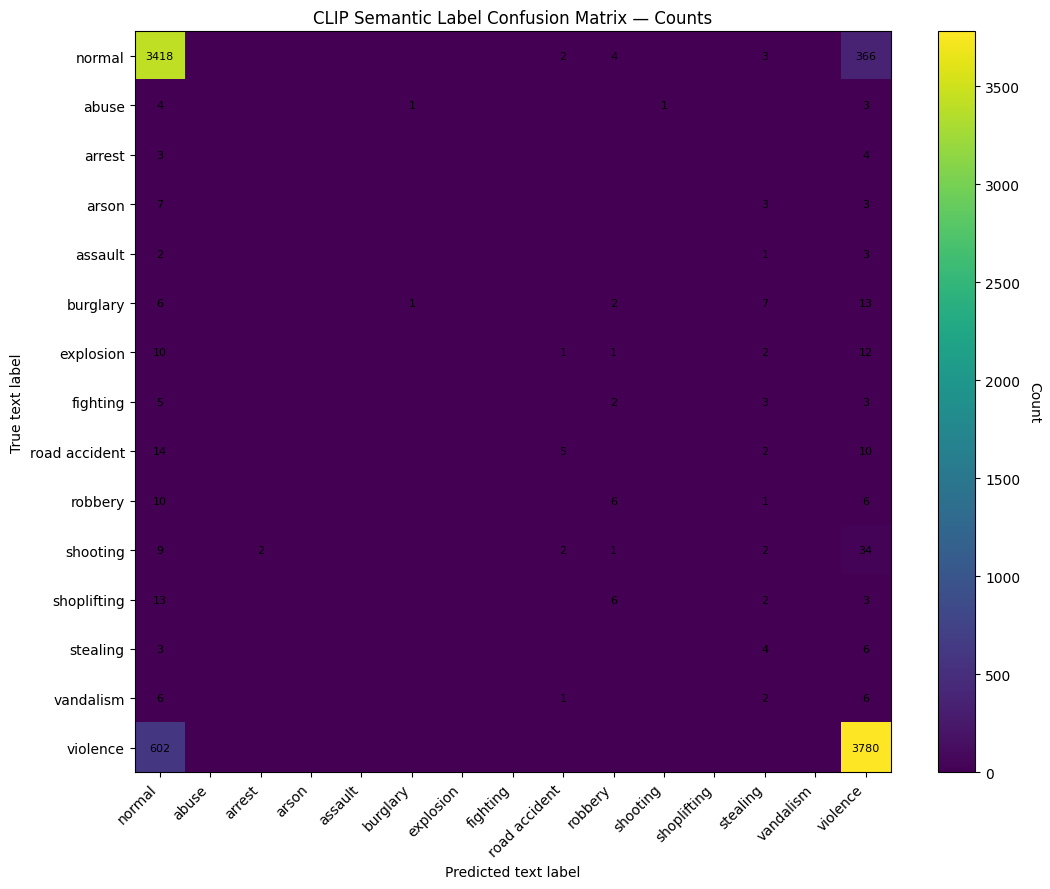

Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/clip_text_confusion_matrix_normalized_by_true.png


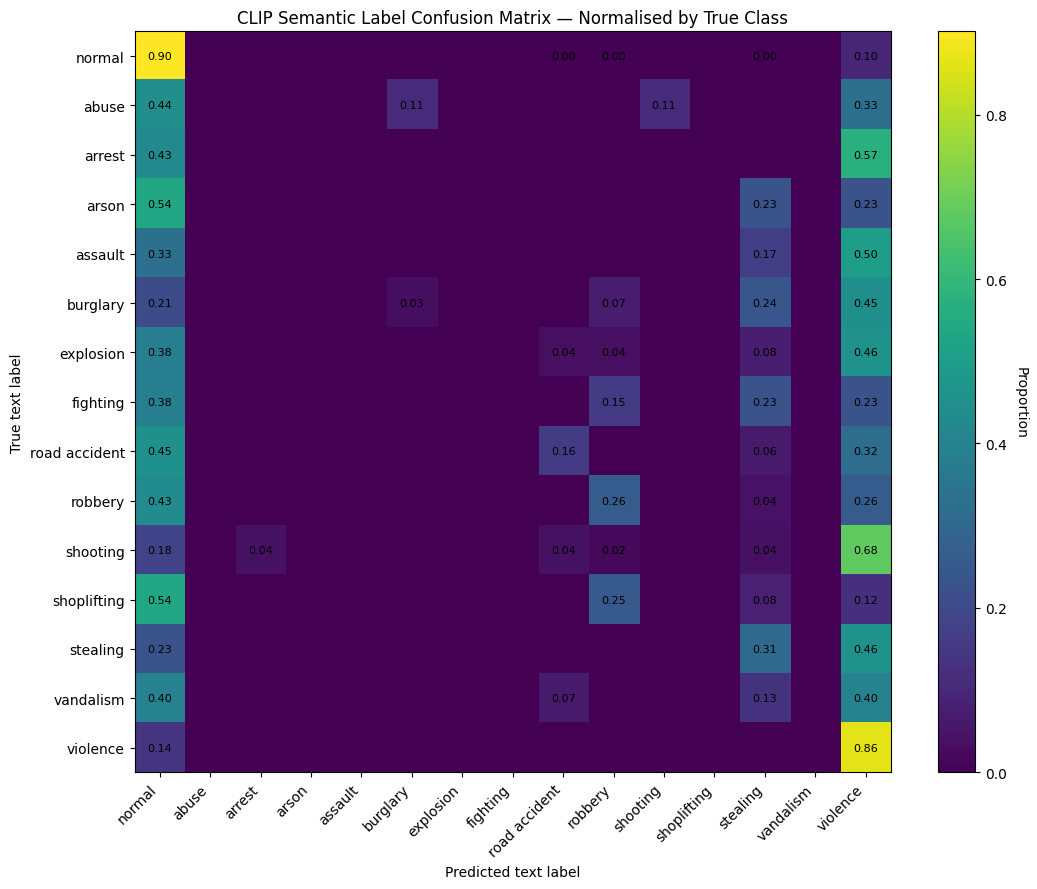

CLIP TEXT SEMANTIC CLASSIFICATION REPORT
Overall semantic-label accuracy: 0.8553
Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/clip_text_classification_report.csv


,precision,recall,f1-score,support
normal,0.8312,0.9011,0.8648,3793.0000
abuse,0.0000,0.0000,0.0000,9.0000
arrest,0.0000,0.0000,0.0000,7.0000
arson,0.0000,0.0000,0.0000,13.0000
assault,0.0000,0.0000,0.0000,6.0000
burglary,0.5000,0.0345,0.0645,29.0000
explosion,0.0000,0.0000,0.0000,26.0000
fighting,0.0000,0.0000,0.0000,13.0000
road accident,0.4545,0.1613,0.2381,31.0000
robbery,0.2727,0.2609,0.2667,23.0000


Saved: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/clip_text_binary_confusion_matrix_counts.csv


,pred_normal,pred_anomaly
true_normal,3418,375
true_anomaly,694,3947


Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/clip_text_binary_confusion_matrix_counts.png


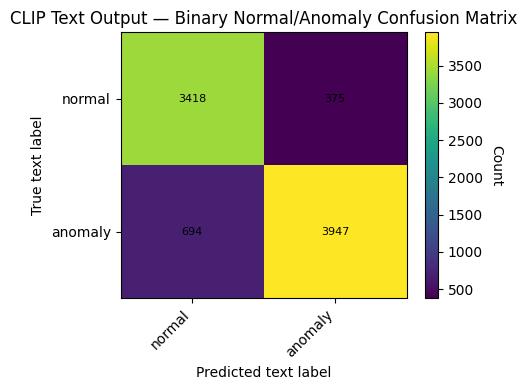

Binary normal/anomaly accuracy from CLIP text labels: 0.8733
CLIP TEXT CONFUSION MATRIX COMPLETE
Saved evaluated predictions: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/clip_text_semantic_predictions_with_eval_labels.csv
Saved multiclass count matrix: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/clip_text_confusion_matrix_counts.csv
Saved multiclass normalised matrix: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/clip_text_confusion_matrix_normalized_by_true.csv
Saved classification report: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/clip_text_classification_report.csv
Saved 

In [28]:
# ============================================================================
# CLIP TEXT SEMANTIC CONFUSION MATRIX — EXTRA CREDIT EVALUATION
# ============================================================================
# This evaluates the CLIP-based semantic label suggestions produced by:
#   clip_text_semantic_predictions.csv
#
# Important:
# These are semantic label suggestions, not fully supervised multiclass
# anomaly-class predictions.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


# ---------------------------------------------------------------------------
# Locate CLIP semantic prediction output
# ---------------------------------------------------------------------------
clip_pred_path = RESULTS_DIR / "clip_text_semantic_predictions.csv"

if "clip_pred_df" in globals() and isinstance(clip_pred_df, pd.DataFrame) and len(clip_pred_df) > 0:
    clip_eval_df = clip_pred_df.copy()
    print("Using in-memory clip_pred_df.")
elif clip_pred_path.exists():
    clip_eval_df = pd.read_csv(clip_pred_path)
    print("Loaded:", clip_pred_path)
else:
    raise FileNotFoundError(
        f"Could not find {clip_pred_path}. Run the CLIP text semantic extra-credit cell first."
    )


# ---------------------------------------------------------------------------
# Check required columns
# ---------------------------------------------------------------------------
required_cols = [
    "true_text_label_mapped_from_metadata",
    "predicted_text_label",
]

missing_cols = [c for c in required_cols if c not in clip_eval_df.columns]

if missing_cols:
    raise KeyError(
        f"Missing required columns in CLIP prediction output: {missing_cols}. "
        "Expected columns include true_text_label_mapped_from_metadata and predicted_text_label."
    )


# ---------------------------------------------------------------------------
# Clean labels
# ---------------------------------------------------------------------------
clip_eval_df["true_text_label"] = (
    clip_eval_df["true_text_label_mapped_from_metadata"]
    .astype(str)
    .str.strip()
    .str.lower()
)

clip_eval_df["predicted_text_label"] = (
    clip_eval_df["predicted_text_label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove rows with empty/invalid labels
clip_eval_df = clip_eval_df[
    (clip_eval_df["true_text_label"] != "")
    & (clip_eval_df["predicted_text_label"] != "")
    & (clip_eval_df["true_text_label"] != "nan")
    & (clip_eval_df["predicted_text_label"] != "nan")
].copy()

print("Rows used for CLIP confusion matrix:", len(clip_eval_df))


# ---------------------------------------------------------------------------
# Label order
# ---------------------------------------------------------------------------
if "ANOMALY_LABEL_SET" in globals():
    base_label_order = [str(x).strip().lower() for x in ANOMALY_LABEL_SET]
else:
    base_label_order = [
        "normal",
        "abuse",
        "arrest",
        "arson",
        "assault",
        "burglary",
        "explosion",
        "fighting",
        "road accident",
        "robbery",
        "shooting",
        "shoplifting",
        "stealing",
        "vandalism",
        "violence",
    ]

# Include any unexpected labels found in true/pred columns
extra_labels = sorted(
    set(clip_eval_df["true_text_label"].unique()).union(
        set(clip_eval_df["predicted_text_label"].unique())
    )
    - set(base_label_order)
)

label_order = base_label_order + extra_labels

# Only keep labels that appear in this output
label_order = [
    lab for lab in label_order
    if lab in set(clip_eval_df["true_text_label"]).union(set(clip_eval_df["predicted_text_label"]))
]

print("Label order:", label_order)


# ---------------------------------------------------------------------------
# Raw multiclass confusion matrix
# ---------------------------------------------------------------------------
y_true = clip_eval_df["true_text_label"].values
y_pred = clip_eval_df["predicted_text_label"].values

cm_counts = confusion_matrix(y_true, y_pred, labels=label_order)

cm_counts_df = pd.DataFrame(
    cm_counts,
    index=[f"true_{x}" for x in label_order],
    columns=[f"pred_{x}" for x in label_order],
)

cm_counts_path = RESULTS_DIR / "clip_text_confusion_matrix_counts.csv"
cm_counts_df.to_csv(cm_counts_path)

print("Saved:", cm_counts_path)
display(cm_counts_df)


# ---------------------------------------------------------------------------
# Normalised confusion matrix by true class
# ---------------------------------------------------------------------------
row_sums = cm_counts.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm_counts,
    row_sums,
    out=np.zeros_like(cm_counts, dtype=float),
    where=row_sums != 0,
)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"true_{x}" for x in label_order],
    columns=[f"pred_{x}" for x in label_order],
)

cm_norm_path = RESULTS_DIR / "clip_text_confusion_matrix_normalized_by_true.csv"
cm_norm_df.to_csv(cm_norm_path)

print("Saved:", cm_norm_path)
display(cm_norm_df.round(3))


# ---------------------------------------------------------------------------
# Plot helper
# ---------------------------------------------------------------------------
def plot_confusion_matrix_matplotlib(
    cm,
    labels,
    title,
    save_name,
    value_format="d",
    figsize=(10, 8),
):
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(cm, aspect="auto")
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Count" if value_format == "d" else "Proportion", rotation=270, labelpad=15)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted text label")
    ax.set_ylabel("True text label")
    ax.set_title(title)

    # Write values inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]

            if value_format == "d":
                text = f"{int(val)}" if int(val) != 0 else ""
            else:
                text = f"{val:.2f}" if val > 0 else ""

            if text:
                ax.text(j, i, text, ha="center", va="center", fontsize=8)

    plt.tight_layout()

    if "save_fig" in globals():
        save_fig(save_name, fig=fig)
    else:
        out = RESULTS_DIR / "figures" / f"{save_name}.png"
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, dpi=200, bbox_inches="tight")
        print("Saved figure:", out)

    plt.show()


# ---------------------------------------------------------------------------
# Plot raw count confusion matrix
# ---------------------------------------------------------------------------
plot_confusion_matrix_matplotlib(
    cm_counts,
    label_order,
    title="CLIP Semantic Label Confusion Matrix — Counts",
    save_name="clip_text_confusion_matrix_counts",
    value_format="d",
    figsize=(11, 9),
)


# ---------------------------------------------------------------------------
# Plot normalised confusion matrix
# ---------------------------------------------------------------------------
plot_confusion_matrix_matplotlib(
    cm_norm,
    label_order,
    title="CLIP Semantic Label Confusion Matrix — Normalised by True Class",
    save_name="clip_text_confusion_matrix_normalized_by_true",
    value_format=".2f",
    figsize=(11, 9),
)


# ---------------------------------------------------------------------------
# Classification report
# ---------------------------------------------------------------------------
clip_accuracy = accuracy_score(y_true, y_pred)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=label_order,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).T

report_path = RESULTS_DIR / "clip_text_classification_report.csv"
report_df.to_csv(report_path)

print("=" * 80)
print("CLIP TEXT SEMANTIC CLASSIFICATION REPORT")
print("=" * 80)
print("Overall semantic-label accuracy:", round(float(clip_accuracy), 4))
print("Saved:", report_path)
display(report_df.round(4))


# ---------------------------------------------------------------------------
# Optional: binary normal/anomaly confusion matrix from semantic labels
# ---------------------------------------------------------------------------
# This checks whether the CLIP semantic output at least separates normal vs anomaly.
# predicted_text_label == "normal" -> normal
# anything else -> anomaly

if "true_binary_label" in clip_eval_df.columns:
    clip_eval_df["true_binary_from_dataset"] = clip_eval_df["true_binary_label"].astype(int)
else:
    clip_eval_df["true_binary_from_dataset"] = (clip_eval_df["true_text_label"] != "normal").astype(int)

clip_eval_df["pred_binary_from_text"] = (clip_eval_df["predicted_text_label"] != "normal").astype(int)

binary_labels = [0, 1]
binary_names = ["normal", "anomaly"]

cm_binary = confusion_matrix(
    clip_eval_df["true_binary_from_dataset"],
    clip_eval_df["pred_binary_from_text"],
    labels=binary_labels,
)

cm_binary_df = pd.DataFrame(
    cm_binary,
    index=["true_normal", "true_anomaly"],
    columns=["pred_normal", "pred_anomaly"],
)

binary_cm_path = RESULTS_DIR / "clip_text_binary_confusion_matrix_counts.csv"
cm_binary_df.to_csv(binary_cm_path)

print("Saved:", binary_cm_path)
display(cm_binary_df)

plot_confusion_matrix_matplotlib(
    cm_binary,
    binary_names,
    title="CLIP Text Output — Binary Normal/Anomaly Confusion Matrix",
    save_name="clip_text_binary_confusion_matrix_counts",
    value_format="d",
    figsize=(5, 4),
)

binary_accuracy = accuracy_score(
    clip_eval_df["true_binary_from_dataset"],
    clip_eval_df["pred_binary_from_text"],
)

print("Binary normal/anomaly accuracy from CLIP text labels:", round(float(binary_accuracy), 4))


# ---------------------------------------------------------------------------
# Save evaluated dataframe with cleaned labels
# ---------------------------------------------------------------------------
clip_eval_out_path = RESULTS_DIR / "clip_text_semantic_predictions_with_eval_labels.csv"
clip_eval_df.to_csv(clip_eval_out_path, index=False)

print("=" * 80)
print("CLIP TEXT CONFUSION MATRIX COMPLETE")
print("=" * 80)
print("Saved evaluated predictions:", clip_eval_out_path)
print("Saved multiclass count matrix:", cm_counts_path)
print("Saved multiclass normalised matrix:", cm_norm_path)
print("Saved classification report:", report_path)
print("Saved binary matrix:", binary_cm_path)